### Import of libraries and csv file

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, levene, shapiro
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.stats import f_oneway
import matplotlib.pyplot as plt

from scipy.stats import f_oneway, kruskal, stats



sns.set(style='whitegrid')
df = pd.read_csv("fifa21 raw data v2.csv")



C:\Users\Simon\AppData\Local\Temp\ipykernel_2692\1240560688.py:19: DtypeWarning: Columns (76) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("fifa21 raw data v2.csv")


### Dataset head preview

In [2]:
pd.set_option('display.max_columns', None)
df.head()

,ID,Name,LongName,photoUrl,playerUrl,Nationality,Age,↓OVA,POT,Club,Contract,Positions,Height,Weight,Preferred Foot,BOV,Best Position,Joined,Loan Date End,Value,Wage,Release Clause,Attacking,Crossing,Finishing,Heading Accuracy,Short Passing,Volleys,Skill,Dribbling,Curve,FK Accuracy,Long Passing,Ball Control,Movement,Acceleration,Sprint Speed,Agility,Reactions,Balance,Power,Shot Power,Jumping,Stamina,Strength,Long Shots,Mentality,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Defending,Marking,Standing Tackle,Sliding Tackle,Goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total Stats,Base Stats,W/F,SM,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Hits
0,158023,L. Messi,Lionel Messi,https://cdn.sofifa.com/players/158/023/21_60.png,http://sofifa.com/player/158023/lionel-messi/2...,Argentina,33,93,93,\n\n\n\nFC Barcelona,2004 ~ 2021,"RW, ST, CF",170cm,72kg,Left,93,RW,"Jul 1, 2004",NaN,€103.5M,€560K,€138.4M,429,85,95,70,91,88,470,96,93,94,91,96,451,91,80,91,94,95,389,86,68,72,69,94,347,44,40,93,95,75,96,91,32,35,24,54,6,11,15,14,8,2231,466,4 ★,4★,Medium,Low,5 ★,85,92,91,95,38,65,771
1,20801,Cristiano Ronaldo,C. Ronaldo dos Santos Aveiro,https://cdn.sofifa.com/players/020/801/21_60.png,http://sofifa.com/player/20801/c-ronaldo-dos-s...,Portugal,35,92,92,\n\n\n\nJuventus,2018 ~ 2022,"ST, LW",187cm,83kg,Right,92,ST,"Jul 10, 2018",NaN,€63M,€220K,€75.9M,437,84,95,90,82,86,414,88,81,76,77,92,431,87,91,87,95,71,444,94,95,84,78,93,353,63,29,95,82,84,95,84,28,32,24,58,7,11,15,14,11,2221,464,4 ★,5★,High,Low,5 ★,89,93,81,89,35,77,562
2,200389,J. Oblak,Jan Oblak,https://cdn.sofifa.com/players/200/389/21_60.png,http://sofifa.com/player/200389/jan-oblak/210006/,Slovenia,27,91,93,\n\n\n\nAtlético Madrid,2014 ~ 2023,GK,188cm,87kg,Right,91,GK,"Jul 16, 2014",NaN,€120M,€125K,€159.4M,95,13,11,15,43,13,109,12,13,14,40,30,307,43,60,67,88,49,268,59,78,41,78,12,140,34,19,11,65,11,68,57,27,12,18,437,87,92,78,90,90,1413,489,3 ★,1★,Medium,Medium,3 ★,87,92,78,90,52,90,150
3,192985,K. De Bruyne,Kevin De Bruyne,https://cdn.sofifa.com/players/192/985/21_60.png,http://sofifa.com/player/192985/kevin-de-bruyn...,Belgium,29,91,91,\n\n\n\nManchester City,2015 ~ 2023,"CAM, CM",181cm,70kg,Right,91,CAM,"Aug 30, 2015",NaN,€129M,€370K,€161M,407,94,82,55,94,82,441,88,85,83,93,92,398,77,76,78,91,76,408,91,63,89,74,91,408,76,66,88,94,84,91,186,68,65,53,56,15,13,5,10,13,2304,485,5 ★,4★,High,High,4 ★,76,86,93,88,64,78,207
4,190871,Neymar Jr,Neymar da Silva Santos Jr.,https://cdn.sofifa.com/players/190/871/21_60.png,http://sofifa.com/player/190871/neymar-da-silv...,Brazil,28,91,91,\n\n\n\nParis Saint-Germain,2017 ~ 2022,"LW, CAM",175cm,68kg,Right,91,LW,"Aug 3, 2017",NaN,€132M,€270K,€166.5M,408,85,87,62,87,87,448,95,88,89,81,95,453,94,89,96,91,83,357,80,62,81,50,84,356,51,36,87,90,92,93,94,35,30,29,59,9,9,15,15,11,2175,451,5 ★,5★,High,Medium,5 ★,91,85,86,94,36,59,595


### Familiarizing with the data set

In [3]:
# Shape of the data
print("Shape:", df.shape)

# Column names
print("Columns:", df.columns.tolist())

# Data types of each column
print("\nData types:")
print(df.dtypes)

# Basic stats (numeric columns only)
print("\nSummary statistics:")
print(df.describe())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

Shape: (18979, 77)
Columns: ['ID', 'Name', 'LongName', 'photoUrl', 'playerUrl', 'Nationality', 'Age', '↓OVA', 'POT', 'Club', 'Contract', 'Positions', 'Height', 'Weight', 'Preferred Foot', 'BOV', 'Best Position', 'Joined', 'Loan Date End', 'Value', 'Wage', 'Release Clause', 'Attacking', 'Crossing', 'Finishing', 'Heading Accuracy', 'Short Passing', 'Volleys', 'Skill', 'Dribbling', 'Curve', 'FK Accuracy', 'Long Passing', 'Ball Control', 'Movement', 'Acceleration', 'Sprint Speed', 'Agility', 'Reactions', 'Balance', 'Power', 'Shot Power', 'Jumping', 'Stamina', 'Strength', 'Long Shots', 'Mentality', 'Aggression', 'Interceptions', 'Positioning', 'Vision', 'Penalties', 'Composure', 'Defending', 'Marking', 'Standing Tackle', 'Sliding Tackle', 'Goalkeeping', 'GK Diving', 'GK Handling', 'GK Kicking', 'GK Positioning', 'GK Reflexes', 'Total Stats', 'Base Stats', 'W/F', 'SM', 'A/W', 'D/W', 'IR', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY', 'Hits']

Data types:
ID            int64
Name         object
L

# Information of the dataset - phase 1 deliverable part 1 of 3

## overview of the dataset
* A fifa 21 raw dataset that contains data of Fifa 21 players' stats
* the dataset was collected from sofifa.com
* the dataset was collected in a messy way, the dataset is raw and ready for cleaning / exploring

## structure of the data
* each row contains players and their stat lines and relevant information that concerns a football player
* each column represents some form of information to the corresponding player on the row
* there are 18979 obersvations(players) in this data set
* the columns contain ID, player names(short and long), url that redirects to player photo, url that redirects to a player url,
  Nationality, Age,player stats(majority of the columns and are numerous), join date, best position, current position, clubs, contracts, weight
  and height


## Football Player Dataset Column Descriptions

# 🧍‍♂️ General Information
- **ID**: Unique identifier for the player.
- **Name**: Common or known name of the football player (e.g., "Messi").
- **LongName**: Full name of the player (e.g., "Lionel Andrés Messi").
- **photoUrl**: URL linking to the players image.
- **playerUrl**: URL linking to the player’s detailed profile.

# 🌍 Personal Details
- **Nationality**: The country the player represents.
- **Age**: Players age.
- **↓OVA (Overall Rating)**: The current overall ability rating of the player.
- **POT (Potential)**: The maximum potential rating the player can reach.

# 🏟️ Club and Contract
- **Club**: The football club the player is currently signed to.
- **Contract**: Contract duration or expiration date (e.g., "2025").
- **Joined**: Date when the player joined the current club.
- **Loan Date End**: End date of a loan spell, if applicable.

## 📊 Attributes
- **Positions**: All positions the player can play (e.g., CAM, RW).
- **Best Position**: The player's most effective or natural position.
- **Preferred Foot**: Dominant foot (Left or Right).
- **Height**: Player’s height (in cm).
- **Weight**: Player’s weight (in kg).
- **BOV (Best Overall Value)**: Highest overall rating at best position.

# 💰 Market Info
- **Value**: Estimated market value of the player (e.g., €50M).
- **Wage**: Weekly salary (e.g., €200K).
- **Release Clause**: Fee required to buy out the player’s contract.

# 🗡️ Attacking Attributes
- **Crossing**: Ability to deliver crosses.
- **Finishing**: Scoring accuracy inside the box.
- **Heading Accuracy**: Precision of headers.
- **Short Passing**: Accuracy and skill in short passes.
- **Volleys**: Accuracy and technique of volley shots.

# 🪄 Skill Attributes
- **Dribbling**: Control and finesse while dribbling.
- **Curve**: Ability to bend the ball.
- **FK Accuracy**: Accuracy in taking free kicks.
- **Long Passing**: Distance passing ability.
- **Ball Control**: First touch and ball handling.

# 🏃 Movement Attributes
- **Acceleration**: How fast the player reaches top speed.
- **Sprint Speed**: Top speed capability.
- **Agility**: Quickness in direction changes.
- **Reactions**: Speed of response to game situations.
- **Balance**: Stability when moving or under pressure.

# 💪 Power Attributes
- **Shot Power**: Force behind shots.
- **Jumping**: Vertical leap ability.
- **Stamina**: Energy level throughout the match.
- **Strength**: Physicality and power in duels.
- **Long Shots**: Accuracy and power from distance.

# 🧠 Mentality Attributes
- **Aggression**: Willingness to challenge and press.
- **Interceptions**: Ability to read and intercept passes.
- **Positioning**: Awareness to be in the right place offensively.
- **Vision**: Ability to spot and execute plays.
- **Penalties**: Proficiency in taking penalties.
- **Composure**: Staying calm under pressure.

# 🛡️ Defending Attributes
- **Marking**: Tracking opponents off the ball.
- **Standing Tackle**: Success in standing challenges.
- **Sliding Tackle**: Effectiveness of sliding tackles.

# 🧤 Goalkeeping Attributes
*(Only relevant for goalkeepers)*
- **GK Diving**: Diving saves.
- **GK Handling**: Ability to catch/hold the ball.
- **GK Kicking**: Accuracy and distance of kicks.
- **GK Positioning**: Awareness of positioning in goal.
- **GK Reflexes**: Reaction time for quick saves.

# 🧮 Overall Metrics
- **Total Stats**: Sum of all stat attributes.
- **Base Stats**: Usually the sum of six key attributes: PAC, SHO, PAS, DRI, DEF, PHY.

# 🔢 Traits and Ratings
- **W/F (Weak Foot)**: Rating of player's non-dominant foot (1–5 stars).
- **SM (Skill Moves)**: Technical skill and flair (1–5 stars).
- **A/W (Attacking Work Rate)**: Attacking effort (Low, Medium, High).
- **D/W (Defensive Work Rate)**: Defensive effort (Low, Medium, High).
- **IR (International Reputation)**: Recognition level (1–5 stars).

# 🔻 Summary Stats
- **PAC (Pace)**: Combined acceleration and sprint speed.
- **SHO (Shooting)**: Combined shooting-related stats.
- **PAS (Passing)**: Combined passing-related stats.
- **DRI (Dribbling)**: Combined dribbling and control stats.
- **DEF (Defending)**: Combined defensive stats.
- **PHY (Physical)**: Combined physical attributes.

# 📈 Popularity
- **Hits**: Number of profile views or interactions.

## Cleaning of dataset - Phase 1 delivarable 2 of 3

### Identifying the dataset, firstly the datatypes and the counts of the datas must first be known so that the these datas may be cleaned using the appropriate approach

In [4]:
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_colwidth', None)  # Prevent cutoff in cell values
pd.set_option('display.expand_frame_repr', False)  # Don't break DataFrame into multiple lines
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18979 entries, 0 to 18978
Data columns (total 77 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ID                18979 non-null  int64 
 1   Name              18979 non-null  object
 2   LongName          18979 non-null  object
 3   photoUrl          18979 non-null  object
 4   playerUrl         18979 non-null  object
 5   Nationality       18979 non-null  object
 6   Age               18979 non-null  int64 
 7   ↓OVA              18979 non-null  int64 
 8   POT               18979 non-null  int64 
 9   Club              18979 non-null  object
 10  Contract          18979 non-null  object
 11  Positions         18979 non-null  object
 12  Height            18979 non-null  object
 13  Weight            18979 non-null  object
 14  Preferred Foot    18979 non-null  object
 15  BOV               18979 non-null  int64 
 16  Best Position     18979 non-null  object
 17  Joined      

The counts of data for each column, for the most part, match the counts of data entries, threre are columns such as, loan date end and hits which do not have the same # of entries as players and because they are irrelivant to our general question, they will be removed.

In [5]:
df.drop(columns=['Hits', 'Loan Date End'], inplace=True)


following data are not relevant to our general question or can be removed because they do not concern the contents of the data set:
PhotoUrl
PlayerUrl


In [6]:
df.drop(columns=[ 'photoUrl', 'playerUrl'], inplace=True)

Lets first check if there are any duplicate players, since each player posseses a unique ID we can check if there are duplicates, we will not be using name or longname for determining if there are duplicates due to the fact players can posses the same name, especially if the name is abbreviated 

In [7]:
df['ID'].duplicated().sum()

np.int64(0)

there is no duplicate player ID thus we can proceed

weight and height are crucial data for our general research question, thus these data must be cleaned

Height and Weight are not in datatypes that can be easily used for statistics, they will be converted into float64

In [8]:
def convert_height(val):
    if isinstance(val, str):
        val = val.strip()
        if val.endswith("cm"):
            try:
                return float(val.replace("cm", ""))
            except:
                return np.nan
        elif "'" in val and '"' in val:
            try:
                feet, inches = val.split("'")
                inches = inches.replace('"', '')
                return int(feet) * 30.48 + int(inches) * 2.54
            except:
                return np.nan
    return np.nan

df['Height'] = df['Height'].apply(convert_height)
df['Height'].dtype


dtype('float64')

displays the converted height

In [9]:
df['Height']

0        170.0
1        187.0
2        188.0
3        181.0
4        175.0
         ...  
18974    178.0
18975    175.0
18976    179.0
18977    175.0
18978    188.0
Name: Height, Length: 18979, dtype: float64

currently all weight is in a strign format, convert it into float 64, first remove all kg attached to the weight

In [10]:
df['Weight'] = df['Weight'].str.replace('kg', '', regex=False).str.strip()
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')

In [11]:
df.rename(columns={'Weight': 'Weight in kg'}, inplace=True)


In [12]:
print(df.dtypes)  # Should show 'Weight in kg' as float64
print(df[['Weight in kg']].head())  # Preview first few rows

ID              int64
Name           object
LongName       object
Nationality    object
Age             int64
                ...  
SHO             int64
PAS             int64
DRI             int64
DEF             int64
PHY             int64
Length: 73, dtype: object
   Weight in kg
0          72.0
1          83.0
2          87.0
3          70.0
4          68.0


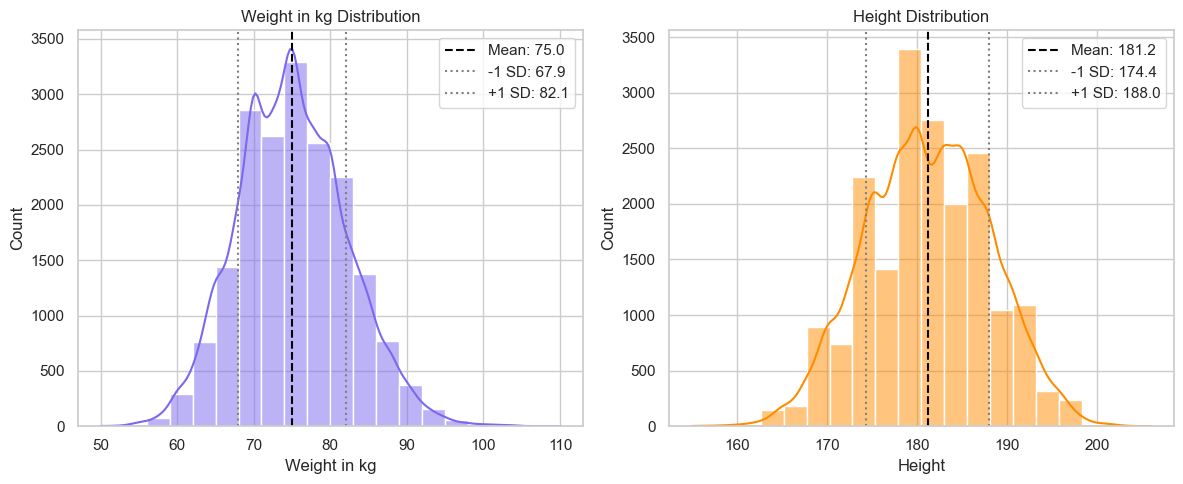

In [13]:
# Columns to visualize
cols = ['Weight in kg', 'Height']
colors = ['mediumslateblue', 'darkorange']

# Create subplots
plt.figure(figsize=(12, 5))

for i, col in enumerate(cols):
    mean = df[col].mean()
    std = df[col].std()

    plt.subplot(1, 2, i+1)
    sns.histplot(df[col], kde=True, bins=20, color=colors[i])
    
    # Mean line
    plt.axvline(mean, color='black', linestyle='--', label=f'Mean: {mean:.1f}')
    
    # ±1 SD lines
    plt.axvline(mean - std, color='gray', linestyle=':', label=f'-1 SD: {mean - std:.1f}')
    plt.axvline(mean + std, color='gray', linestyle=':', label=f'+1 SD: {mean + std:.1f}')
    
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend()

plt.tight_layout()
plt.show()

In [14]:
df['Log_Weight'] = np.log(df['Weight in kg'])

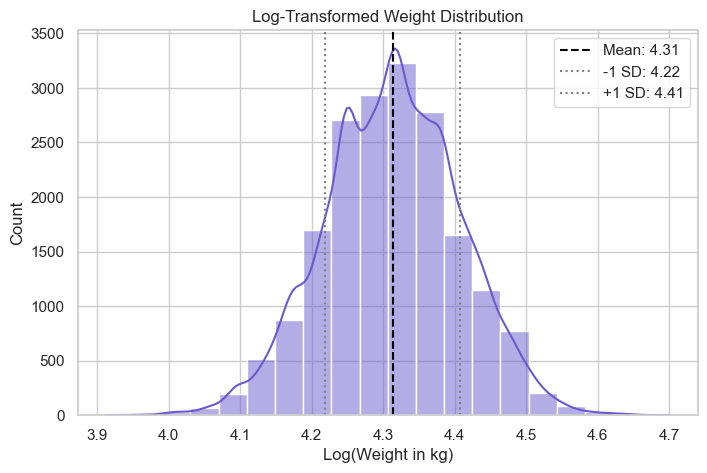

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Log_Weight'], kde=True, bins=20, color='slateblue')

mean_log = df['Log_Weight'].mean()
std_log = df['Log_Weight'].std()

# Overlay Mean and ±1 SD lines
plt.axvline(mean_log, color='black', linestyle='--', label=f'Mean: {mean_log:.2f}')
plt.axvline(mean_log - std_log, color='gray', linestyle=':', label=f'-1 SD: {mean_log - std_log:.2f}')
plt.axvline(mean_log + std_log, color='gray', linestyle=':', label=f'+1 SD: {mean_log + std_log:.2f}')

plt.title('Log-Transformed Weight Distribution')
plt.xlabel('Log(Weight in kg)')
plt.ylabel('Count')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
df.rename(columns={'↓OVA': 'OVA'}, inplace=True)

In [17]:
print(df[['Age', 'OVA', 'POT']].describe())

                Age           OVA           POT
count  18979.000000  18979.000000  18979.000000
mean      25.194109     65.718636     71.136414
std        4.710520      6.968999      6.114635
min       16.000000     47.000000     47.000000
25%       21.000000     61.000000     67.000000
50%       25.000000     66.000000     71.000000
75%       29.000000     70.000000     75.000000
max       53.000000     93.000000     95.000000


In [18]:
# Ages below 15 or above 50
df[(df['Age'] < 15) | (df['Age'] > 50)]

,ID,Name,LongName,Nationality,Age,OVA,POT,Club,Contract,Positions,Height,Weight in kg,Preferred Foot,BOV,Best Position,Joined,Value,Wage,Release Clause,Attacking,Crossing,Finishing,Heading Accuracy,Short Passing,Volleys,Skill,Dribbling,Curve,FK Accuracy,Long Passing,Ball Control,Movement,Acceleration,Sprint Speed,Agility,Reactions,Balance,Power,Shot Power,Jumping,Stamina,Strength,Long Shots,Mentality,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Defending,Marking,Standing Tackle,Sliding Tackle,Goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total Stats,Base Stats,W/F,SM,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Log_Weight
16109,254704,K. Miura,Kazuyoshi Miura,Japan,53,59,59,\n\n\n\nYokohama FC,2005 ~ 2021,ST,177.0,72.0,Right,60,CF,"Jul 1, 2005",€0,€700,€0,289,44,66,56,61,62,290,63,69,54,36,68,187,24,26,27,48,62,235,59,32,21,62,61,257,45,16,71,66,59,77,42,16,13,13,41,6,14,8,6,7,1341,269,4 ★,2★,Low,Low,1 ★,25,63,55,60,19,47,4.276666


In [19]:
# OVA or POT out of bounds
df[(df['OVA'] < 40) | (df['OVA'] > 99)]
df[(df['POT'] < 40) | (df['POT'] > 99)]

,ID,Name,LongName,Nationality,Age,OVA,POT,Club,Contract,Positions,Height,Weight in kg,Preferred Foot,BOV,Best Position,Joined,Value,Wage,Release Clause,Attacking,Crossing,Finishing,Heading Accuracy,Short Passing,Volleys,Skill,Dribbling,Curve,FK Accuracy,Long Passing,Ball Control,Movement,Acceleration,Sprint Speed,Agility,Reactions,Balance,Power,Shot Power,Jumping,Stamina,Strength,Long Shots,Mentality,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Defending,Marking,Standing Tackle,Sliding Tackle,Goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total Stats,Base Stats,W/F,SM,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Log_Weight


In [20]:
df[df['OVA'] > df['POT']]

,ID,Name,LongName,Nationality,Age,OVA,POT,Club,Contract,Positions,Height,Weight in kg,Preferred Foot,BOV,Best Position,Joined,Value,Wage,Release Clause,Attacking,Crossing,Finishing,Heading Accuracy,Short Passing,Volleys,Skill,Dribbling,Curve,FK Accuracy,Long Passing,Ball Control,Movement,Acceleration,Sprint Speed,Agility,Reactions,Balance,Power,Shot Power,Jumping,Stamina,Strength,Long Shots,Mentality,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Defending,Marking,Standing Tackle,Sliding Tackle,Goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total Stats,Base Stats,W/F,SM,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Log_Weight


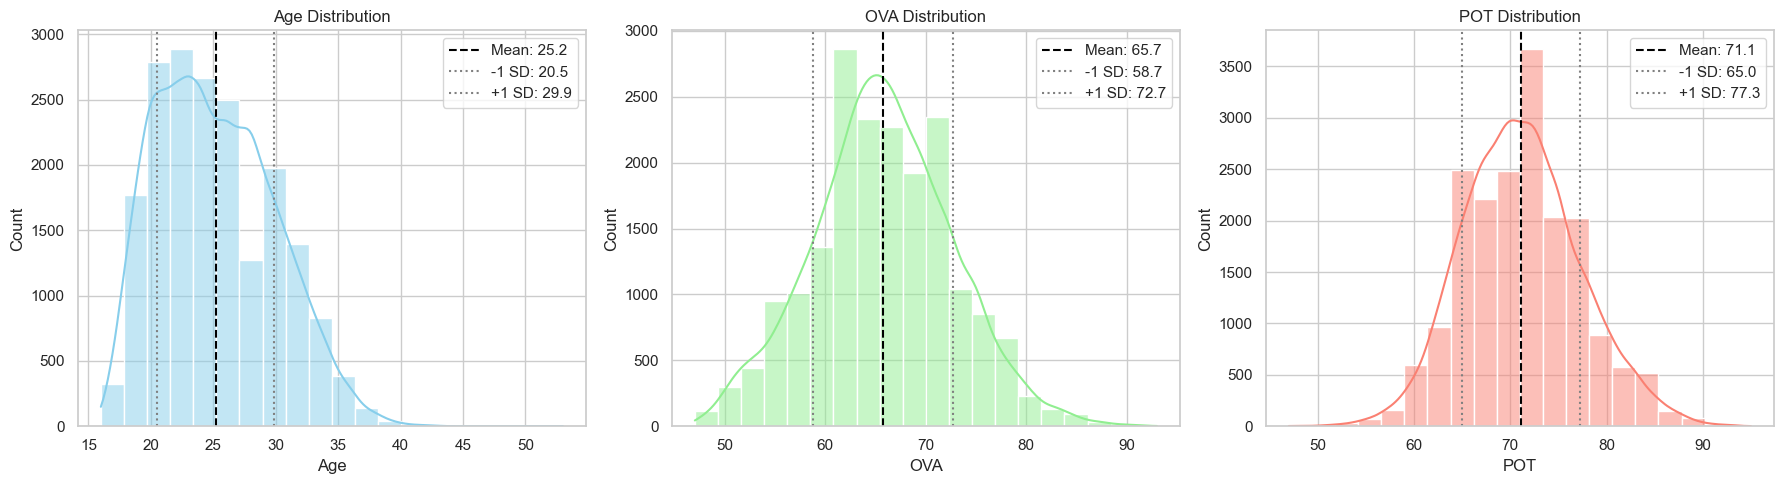

In [21]:
# Set plot style
sns.set(style="whitegrid")

# List of variables to plot
cols = ['Age', 'OVA', 'POT']
colors = ['skyblue', 'lightgreen', 'salmon']

# Create subplots
plt.figure(figsize=(18, 5))

for i, col in enumerate(cols):
    mean = df[col].mean()
    std = df[col].std()
    
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col], kde=True, bins=20, color=colors[i])
    
    # Mean line
    plt.axvline(mean, color='black', linestyle='--', label=f'Mean: {mean:.1f}')
    
    # ±1 SD lines
    plt.axvline(mean - std, color='gray', linestyle=':', label=f'-1 SD: {mean - std:.1f}')
    plt.axvline(mean + std, color='gray', linestyle=':', label=f'+1 SD: {mean + std:.1f}')
    
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend()

plt.tight_layout()
plt.show()

In [22]:
df['Club'].value_counts().head(20)


Club
No Club                        237
\n\n\n\nRC Celta                33
\n\n\n\nEverton                 33
\n\n\n\nManchester United       33
\n\n\n\nLeicester City          33
\n\n\n\nFC Barcelona            33
\n\n\n\nCrystal Palace          33
\n\n\n\nTorino                  33
\n\n\n\nLiverpool               33
\n\n\n\nArsenal                 33
\n\n\n\nTottenham Hotspur       33
\n\n\n\nChelsea                 33
\n\n\n\nWest Ham United         33
\n\n\n\nFulham                  33
\n\n\n\nNewcastle United        33
\n\n\n\nReal Valladolid CF      33
\n\n\n\nTSG 1899 Hoffenheim     33
\n\n\n\nGenoa                   33
\n\n\n\nValencia CF             33
\n\n\n\nReal Betis              33
Name: count, dtype: int64

In [23]:
vc = df['Club'].value_counts()
vc[vc < 11]  # shows clubs with < 5 players

Series([], Name: count, dtype: int64)

In [24]:
df['Club'].nunique()

682

In [25]:
df['Club'].isna().sum()      
df['Club'].eq('').sum()    

np.int64(0)

In [26]:
df['Club'] = df['Club'].str.strip()

In [27]:
df['Contract'].value_counts(dropna=False).head(100)

Contract
2019 ~ 2021             1706
2020 ~ 2022             1445
2020 ~ 2021             1440
2019 ~ 2022             1236
2018 ~ 2021             1163
                        ... 
2007 ~ 2023                2
2009 ~ 2024                2
2006 ~ 2020                2
2007 ~ 2020                2
Aug 31, 2021 On Loan       2
Name: count, Length: 100, dtype: int64

In [28]:
df['Contract'].unique()

array(['2004 ~ 2021', '2018 ~ 2022', '2014 ~ 2023', '2015 ~ 2023',
       '2017 ~ 2022', '2017 ~ 2023', '2018 ~ 2024', '2014 ~ 2022',
       '2018 ~ 2023', '2016 ~ 2023', '2013 ~ 2023', '2011 ~ 2023',
       '2009 ~ 2022', '2005 ~ 2021', '2011 ~ 2021', '2015 ~ 2022',
       '2017 ~ 2024', '2010 ~ 2024', '2012 ~ 2021', '2019 ~ 2024',
       '2015 ~ 2024', '2017 ~ 2025', '2020 ~ 2025', '2019 ~ 2023',
       '2008 ~ 2023', '2015 ~ 2021', '2020 ~ 2022', '2012 ~ 2022',
       '2016 ~ 2025', '2013 ~ 2022', '2011 ~ 2022', '2012 ~ 2024',
       '2016 ~ 2021', '2012 ~ 2023', '2008 ~ 2022', '2019 ~ 2022',
       '2017 ~ 2021', '2013 ~ 2024', '2020 ~ 2024', '2010 ~ 2022',
       '2020 ~ 2021', '2011 ~ 2024', '2020 ~ 2023', '2014 ~ 2024',
       '2013 ~ 2026', '2016 ~ 2022', '2010 ~ 2021', '2013 ~ 2021',
       '2019 ~ 2025', '2018 ~ 2025', '2016 ~ 2024', '2018 ~ 2021',
       '2009 ~ 2024', '2007 ~ 2022', 'Jun 30, 2021 On Loan',
       '2009 ~ 2021', '2019 ~ 2021', '2019 ~ 2026', 'Free', '2012 ~ 

In [29]:
df['Contract'] = df['Contract'].str.strip()

In [30]:
def get_contract_type(val):
    val = val.strip()
    if val == 'Free':
        return 'Free Agent'
    elif 'On Loan' in val:
        return 'Loan'
    elif '~' in val:
        return 'Fixed Contract'
    else:
        return 'Unknown'

df['Contract_Type'] = df['Contract'].apply(get_contract_type)


In [31]:
# Only apply to rows with 'Fixed Contract'
fixed_contracts = df['Contract_Type'] == 'Fixed Contract'

df.loc[fixed_contracts, 'Contract_Start'] = df.loc[fixed_contracts, 'Contract'].str.extract(r'(\d{4})')
df.loc[fixed_contracts, 'Contract_End'] = df.loc[fixed_contracts, 'Contract'].str.extract(r'~\s*(\d{4})')


In [32]:
df['Contract_Start'] = pd.to_numeric(df['Contract_Start'], errors='coerce')
df['Contract_End'] = pd.to_numeric(df['Contract_End'], errors='coerce')

In [33]:
df['Contract_Type'].value_counts()

Contract_Type
Fixed Contract    17729
Loan               1013
Free Agent          237
Name: count, dtype: int64

In [34]:
df[df['Contract_Type'] == 'Unknown']


,ID,Name,LongName,Nationality,Age,OVA,POT,Club,Contract,Positions,Height,Weight in kg,Preferred Foot,BOV,Best Position,Joined,Value,Wage,Release Clause,Attacking,Crossing,Finishing,Heading Accuracy,Short Passing,Volleys,Skill,Dribbling,Curve,FK Accuracy,Long Passing,Ball Control,Movement,Acceleration,Sprint Speed,Agility,Reactions,Balance,Power,Shot Power,Jumping,Stamina,Strength,Long Shots,Mentality,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Defending,Marking,Standing Tackle,Sliding Tackle,Goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total Stats,Base Stats,W/F,SM,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Log_Weight,Contract_Type,Contract_Start,Contract_End


In [35]:
df['Positions'].value_counts().head(100)

Positions
CB             2441
GK             2074
ST             1864
CDM, CM         842
CM              795
               ... 
LW, CAM          17
RM, LM, CM       17
CDM, CM, RB      17
ST, CAM, LM      17
CB, CM           16
Name: count, Length: 100, dtype: int64

In [36]:
# Remove leading/trailing spaces & split on commas
df['Position_List'] = df['Positions'].apply(lambda x: [p.strip() for p in str(x).split(',')])


In [37]:
df['Primary_Position'] = df['Position_List'].apply(lambda x: x[0] if len(x) > 0 else None)


In [38]:
def position_group(pos):
    if pos == 'GK':
        return 'Goalkeeper'
    elif pos in ['CB', 'LB', 'RB', 'LWB', 'RWB']:
        return 'Defender'
    elif pos in ['CDM', 'CM', 'CAM', 'LM', 'RM']:
        return 'Midfielder'
    elif pos in ['ST', 'CF', 'LW', 'RW']:
        return 'Forward'
    else:
        return 'Other'

df['Position_Group'] = df['Primary_Position'].apply(position_group)


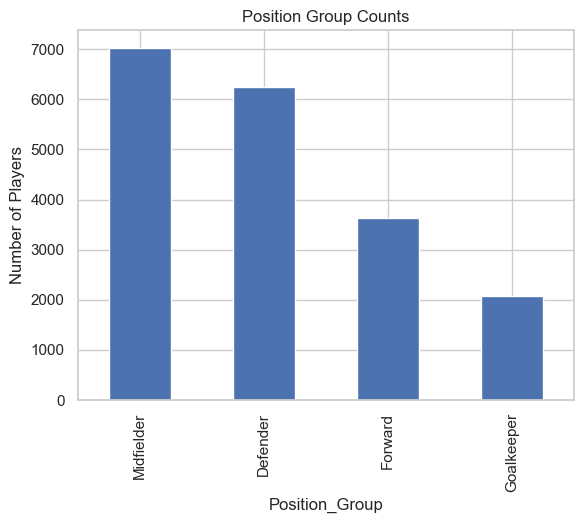

In [39]:
df['Position_Group'].value_counts().plot(kind='bar', title='Position Group Counts')
plt.ylabel('Number of Players')
plt.show()

In [40]:
df['Primary_Position'].value_counts()

Primary_Position
CB     3278
ST     2628
CM     2228
GK     2075
CDM    1526
LB     1399
RB     1365
CAM    1155
RM     1067
LM     1053
RW      446
LW      436
CF      118
LWB     104
RWB     101
Name: count, dtype: int64

In [41]:
df['Position_Group'].value_counts()

Position_Group
Midfielder    7029
Defender      6247
Forward       3628
Goalkeeper    2075
Name: count, dtype: int64

In [42]:
df['Position_Count'] = df['Position_List'].apply(len)
df['Position_Count'].describe()

count    18979.000000
mean         1.606671
std          0.705906
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          3.000000
Name: Position_Count, dtype: float64

In [43]:
df['Preferred Foot'].value_counts(dropna=False)

Preferred Foot
Right    14445
Left      4534
Name: count, dtype: int64

In [44]:
df['Preferred Foot'] = df['Preferred Foot'].str.strip().str.title()

In [45]:
df['BOV'].describe()

count    18979.000000
mean        66.751726
std          6.747193
min         48.000000
25%         62.000000
50%         67.000000
75%         71.000000
max         93.000000
Name: BOV, dtype: float64

In [46]:
df[df['BOV'] > 86]

,ID,Name,LongName,Nationality,Age,OVA,POT,Club,Contract,Positions,Height,Weight in kg,Preferred Foot,BOV,Best Position,Joined,Value,Wage,Release Clause,Attacking,Crossing,Finishing,Heading Accuracy,Short Passing,Volleys,Skill,Dribbling,Curve,FK Accuracy,Long Passing,Ball Control,Movement,Acceleration,Sprint Speed,Agility,Reactions,Balance,Power,Shot Power,Jumping,Stamina,Strength,Long Shots,Mentality,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Defending,Marking,Standing Tackle,Sliding Tackle,Goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total Stats,Base Stats,W/F,SM,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Log_Weight,Contract_Type,Contract_Start,Contract_End,Position_List,Primary_Position,Position_Group,Position_Count
0,158023,L. Messi,Lionel Messi,Argentina,33,93,93,FC Barcelona,2004 ~ 2021,"RW, ST, CF",170.0,72.0,Left,93,RW,"Jul 1, 2004",€103.5M,€560K,€138.4M,429,85,95,70,91,88,470,96,93,94,91,96,451,91,80,91,94,95,389,86,68,72,69,94,347,44,40,93,95,75,96,91,32,35,24,54,6,11,15,14,8,2231,466,4 ★,4★,Medium,Low,5 ★,85,92,91,95,38,65,4.276666,Fixed Contract,NaN,NaN,"[RW, ST, CF]",RW,Forward,3
1,20801,Cristiano Ronaldo,C. Ronaldo dos Santos Aveiro,Portugal,35,92,92,Juventus,2018 ~ 2022,"ST, LW",187.0,83.0,Right,92,ST,"Jul 10, 2018",€63M,€220K,€75.9M,437,84,95,90,82,86,414,88,81,76,77,92,431,87,91,87,95,71,444,94,95,84,78,93,353,63,29,95,82,84,95,84,28,32,24,58,7,11,15,14,11,2221,464,4 ★,5★,High,Low,5 ★,89,93,81,89,35,77,4.418841,Fixed Contract,NaN,NaN,"[ST, LW]",ST,Forward,2
2,200389,J. Oblak,Jan Oblak,Slovenia,27,91,93,Atlético Madrid,2014 ~ 2023,GK,188.0,87.0,Right,91,GK,"Jul 16, 2014",€120M,€125K,€159.4M,95,13,11,15,43,13,109,12,13,14,40,30,307,43,60,67,88,49,268,59,78,41,78,12,140,34,19,11,65,11,68,57,27,12,18,437,87,92,78,90,90,1413,489,3 ★,1★,Medium,Medium,3 ★,87,92,78,90,52,90,4.465908,Fixed Contract,NaN,NaN,[GK],GK,Goalkeeper,1
3,192985,K. De Bruyne,Kevin De Bruyne,Belgium,29,91,91,Manchester City,2015 ~ 2023,"CAM, CM",181.0,70.0,Right,91,CAM,"Aug 30, 2015",€129M,€370K,€161M,407,94,82,55,94,82,441,88,85,83,93,92,398,77,76,78,91,76,408,91,63,89,74,91,408,76,66,88,94,84,91,186,68,65,53,56,15,13,5,10,13,2304,485,5 ★,4★,High,High,4 ★,76,86,93,88,64,78,4.248495,Fixed Contract,NaN,NaN,"[CAM, CM]",CAM,Midfielder,2
4,190871,Neymar Jr,Neymar da Silva Santos Jr.,Brazil,28,91,91,Paris Saint-Germain,2017 ~ 2022,"LW, CAM",175.0,68.0,Right,91,LW,"Aug 3, 2017",€132M,€270K,€166.5M,408,85,87,62,87,87,448,95,88,89,81,95,453,94,89,96,91,83,357,80,62,81,50,84,356,51,36,87,90,92,93,94,35,30,29,59,9,9,15,15,11,2175,451,5 ★,5★,High,Medium,5 ★,91,85,86,94,36,59,4.219508,Fixed Contract,NaN,NaN,"[LW, CAM]",LW,Forward,2
5,188545,R. Lewandowski,Robert Lewandowski,Poland,31,91,91,FC Bayern München,2014 ~ 2023,ST,184.0,80.0,Right,91,ST,"Jul 1, 2014",€111M,€240K,€132M,423,71,94,85,84,89,407,85,79,85,70,88,407,77,78,77,93,82,420,89,84,76,86,85,391,81,49,94,79,88,88,96,35,42,19,51,15,6,12,8,10,2195,457,4 ★,4★,High,Medium,4 ★,78,91,78,85,43,82,4.382027,Fixed Contract,NaN,NaN,[ST],ST,Forward,1
6,209331,M. Salah,Mohamed Salah,Egypt,28,90,90,Liverpool,2017 ~ 2023,RW,175.0,71.0,Left,90,RW,"Jul 1, 2017",€120.5M,€250K,€144.3M,392,79,91,59,84,79,406,90,83,69,75,89,460,94,92,91,92,91,393,80,69,85,75,84,376,63,55,91,84,83,90,122,38,43,41,62,14,14,9,11,14,2211,470,3 ★,4★,High,Medium,3 ★,93,86,81,90,45,75,4.262680,Fixed Contract,NaN,NaN,[RW],RW,Forward,1
7,212831,Alisson,Alisson Ramses Becker,Brazil,27,90,91,Liverpool,2018 ~ 2024,GK,191.0,91.0,Right,90,GK,"Jul 19, 2018",€102M,€160K,€120.3M,114,17,13,19,45,20,138,27,19,18,44,30,268,56,47,40,88,37,240,64,52,32,78,14,140,27,11,13,66,23,65,50,15,19,16,439,86,88,85,91,89,1389,490,3 ★,1★,Medium,Medium,3 ★,86,88,85,89,51,91,4.510860,Fixed Contract,NaN,NaN,[GK],GK,Goalkeeper,1
8,231747,K. Mbappé,Kylian Mbappé,France,21,90,95,Paris Saint-Germain,2018 ~ 2022,"ST, LW, RW",178.0,73.0,Right,91,ST,"Jul 1, 2018",€185.5M,€160K,€203.1M,408,78,91,73,83,83,394,92,79,63,70,90,458,96,96,92,92,82,

In [47]:
df['Best Position'].value_counts()

Best Position
CB     3686
ST     2680
CAM    2299
GK     2075
RM     1611
CDM    1445
LB     1086
RB     1079
CM     1047
LM      871
RW      298
RWB     277
LWB     261
LW      186
CF       78
Name: count, dtype: int64

In [48]:
df['Joined'] = pd.to_datetime(df['Joined'], errors='coerce')

In [49]:
df['Joined'].isnull().sum()

np.int64(0)

In [50]:
def money_to_float(value_str):
    if isinstance(value_str, str):
        value_str = value_str.replace('€', '').replace(',', '').strip()
        if value_str.endswith('M'):
            return float(value_str[:-1]) * 1_000_000
        elif value_str.endswith('K'):
            return float(value_str[:-1]) * 1_000
        else:
            try:
                return float(value_str)
            except:
                return None
    return None

df['Value'] = df['Value'].apply(money_to_float)
df['Wage'] = df['Wage'].apply(money_to_float)

In [51]:
(df['Name'] == df['LongName']).value_counts()


False    18940
True        39
Name: count, dtype: int64

In [52]:
df[['Value', 'Wage']].describe()

,Value,Wage
count,1.897900e+04,18979.000000
mean,2.865063e+06,9092.062279
std,7.685154e+06,19707.021089
min,0.000000e+00,0.000000
25%,4.750000e+05,1000.000000
50%,9.500000e+05,3000.000000
75%,2.000000e+06,8000.000000
max,1.855000e+08,560000.000000


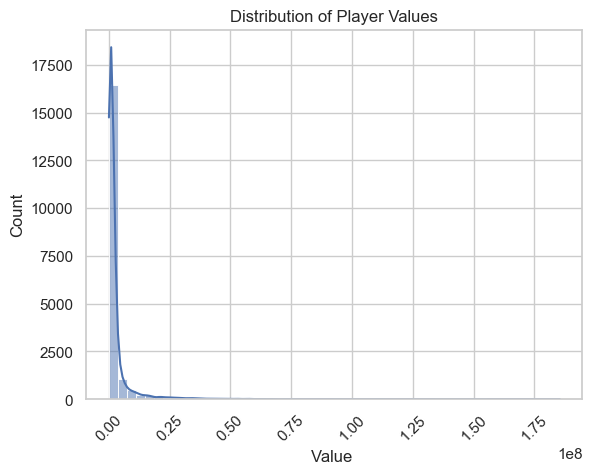

In [53]:
sns.histplot(df['Value'], bins=50, kde=True)
plt.title('Distribution of Player Values')
plt.xlabel('Value ')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

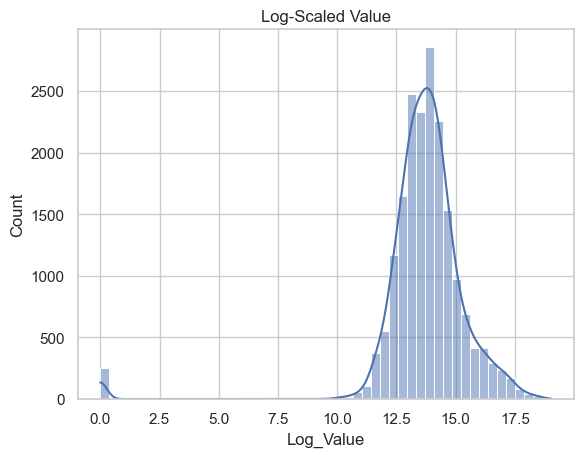

In [54]:
df['Log_Value'] = np.log1p(df['Value'])  # log1p = log(x + 1) to avoid log(0)

sns.histplot(df['Log_Value'], bins=50, kde=True)
plt.title('Log-Scaled Value')
plt.show()

In [55]:
wage_stats = df['Wage'].describe(percentiles=[.25, .5, .75, .90, .95, .99]).to_frame(name='Wage Stats')
print(wage_stats)


          Wage Stats
count   18979.000000
mean     9092.062279
std     19707.021089
min         0.000000
25%      1000.000000
50%      3000.000000
75%      8000.000000
90%     23000.000000
95%     38000.000000
99%     90000.000000
max    560000.000000


In [56]:
# Find the smallest non-zero wage
min_wage = df[df['Value'] > 0]['Value'].min()

# Replace all 0 wages with the minimum non-zero wage
df['Value'] = df['Value'].replace(0, min_wage)

In [57]:
df['Log_Value'] = np.log(df['Value'])

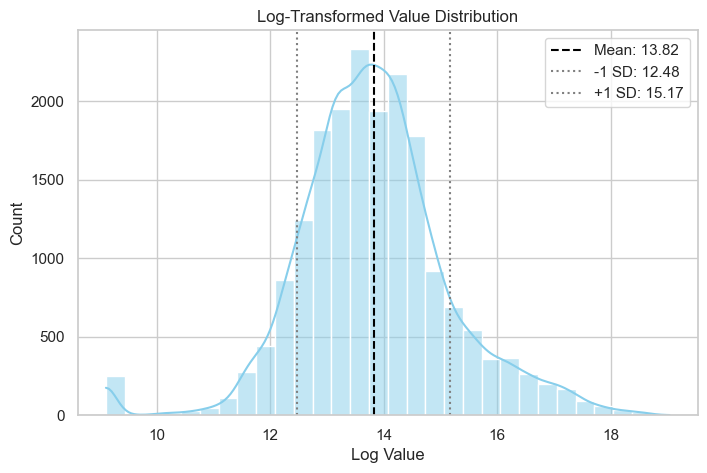

In [58]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Log_Value'], kde=True, bins=30, color='skyblue')

mean_log = df['Log_Value'].mean()
std_log = df['Log_Value'].std()

plt.axvline(mean_log, color='black', linestyle='--', label=f'Mean: {mean_log:.2f}')
plt.axvline(mean_log - std_log, color='gray', linestyle=':', label=f'-1 SD: {mean_log - std_log:.2f}')
plt.axvline(mean_log + std_log, color='gray', linestyle=':', label=f'+1 SD: {mean_log + std_log:.2f}')

plt.title('Log-Transformed Value Distribution')
plt.xlabel('Log Value')
plt.ylabel('Count')
plt.legend()
plt.grid(True)
plt.show()

In [59]:
df[['Name', 'Club', 'Wage']].sort_values(by='Wage', ascending=False).head(10)


,Name,Club,Wage
0,L. Messi,FC Barcelona,560000.0
3,K. De Bruyne,Manchester City,370000.0
15,K. Benzema,Real Madrid,350000.0
26,E. Hazard,Real Madrid,350000.0
27,T. Kroos,Real Madrid,310000.0
12,Casemiro,Real Madrid,310000.0
16,Sergio Ramos,Real Madrid,300000.0
17,S. Agüero,Manchester City,300000.0
28,A. Griezmann,FC Barcelona,290000.0
4,Neymar Jr,Paris Saint-Germain,270000.0


In [60]:
df.head(10)

,ID,Name,LongName,Nationality,Age,OVA,POT,Club,Contract,Positions,Height,Weight in kg,Preferred Foot,BOV,Best Position,Joined,Value,Wage,Release Clause,Attacking,Crossing,Finishing,Heading Accuracy,Short Passing,Volleys,Skill,Dribbling,Curve,FK Accuracy,Long Passing,Ball Control,Movement,Acceleration,Sprint Speed,Agility,Reactions,Balance,Power,Shot Power,Jumping,Stamina,Strength,Long Shots,Mentality,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Defending,Marking,Standing Tackle,Sliding Tackle,Goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total Stats,Base Stats,W/F,SM,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Log_Weight,Contract_Type,Contract_Start,Contract_End,Position_List,Primary_Position,Position_Group,Position_Count,Log_Value
0,158023,L. Messi,Lionel Messi,Argentina,33,93,93,FC Barcelona,2004 ~ 2021,"RW, ST, CF",170.0,72.0,Left,93,RW,2004-07-01,103500000.0,560000.0,€138.4M,429,85,95,70,91,88,470,96,93,94,91,96,451,91,80,91,94,95,389,86,68,72,69,94,347,44,40,93,95,75,96,91,32,35,24,54,6,11,15,14,8,2231,466,4 ★,4★,Medium,Low,5 ★,85,92,91,95,38,65,4.276666,Fixed Contract,NaN,NaN,"[RW, ST, CF]",RW,Forward,3,18.455082
1,20801,Cristiano Ronaldo,C. Ronaldo dos Santos Aveiro,Portugal,35,92,92,Juventus,2018 ~ 2022,"ST, LW",187.0,83.0,Right,92,ST,2018-07-10,63000000.0,220000.0,€75.9M,437,84,95,90,82,86,414,88,81,76,77,92,431,87,91,87,95,71,444,94,95,84,78,93,353,63,29,95,82,84,95,84,28,32,24,58,7,11,15,14,11,2221,464,4 ★,5★,High,Low,5 ★,89,93,81,89,35,77,4.418841,Fixed Contract,NaN,NaN,"[ST, LW]",ST,Forward,2,17.958645
2,200389,J. Oblak,Jan Oblak,Slovenia,27,91,93,Atlético Madrid,2014 ~ 2023,GK,188.0,87.0,Right,91,GK,2014-07-16,120000000.0,125000.0,€159.4M,95,13,11,15,43,13,109,12,13,14,40,30,307,43,60,67,88,49,268,59,78,41,78,12,140,34,19,11,65,11,68,57,27,12,18,437,87,92,78,90,90,1413,489,3 ★,1★,Medium,Medium,3 ★,87,92,78,90,52,90,4.465908,Fixed Contract,NaN,NaN,[GK],GK,Goalkeeper,1,18.603002
3,192985,K. De Bruyne,Kevin De Bruyne,Belgium,29,91,91,Manchester City,2015 ~ 2023,"CAM, CM",181.0,70.0,Right,91,CAM,2015-08-30,129000000.0,370000.0,€161M,407,94,82,55,94,82,441,88,85,83,93,92,398,77,76,78,91,76,408,91,63,89,74,91,408,76,66,88,94,84,91,186,68,65,53,56,15,13,5,10,13,2304,485,5 ★,4★,High,High,4 ★,76,86,93,88,64,78,4.248495,Fixed Contract,NaN,NaN,"[CAM, CM]",CAM,Midfielder,2,18.675323
4,190871,Neymar Jr,Neymar da Silva Santos Jr.,Brazil,28,91,91,Paris Saint-Germain,2017 ~ 2022,"LW, CAM",175.0,68.0,Right,91,LW,2017-08-03,132000000.0,270000.0,€166.5M,408,85,87,62,87,87,448,95,88,89,81,95,453,94,89,96,91,83,357,80,62,81,50,84,356,51,36,87,90,92,93,94,35,30,29,59,9,9,15,15,11,2175,451,5 ★,5★,High,Medium,5 ★,91,85,86,94,36,59,4.219508,Fixed Contract,NaN,NaN,"[LW, CAM]",LW,Forward,2,18.698312
5,188545,R. Lewandowski,Robert Lewandowski,Poland,31,91,91,FC Bayern München,2014 ~ 2023,ST,184.0,80.0,Right,91,ST,2014-07-01,111000000.0,240000.0,€132M,423,71,94,85,84,89,407,85,79,85,70,88,407,77,78,77,93,82,420,89,84,76,86,85,391,81,49,94,79,88,88,96,35,42,19,51,15,6,12,8,10,2195,457,4 ★,4★,High,Medium,4 ★,78,91,78,85,43,82,4.382027,Fixed Contract,NaN,NaN,[ST],ST,Forward,1,18.525041
6,209331,M. Salah,Mohamed Salah,Egypt,28,90,90,Liverpool,2017 ~ 2023,RW,175.0,71.0,Left,90,RW,2017-07-01,120500000.0,250000.0,€144.3M,392,79,91,59,84,79,406,90,83,69,75,89,460,94,92,91,92,91,393,80,69,85,75,84,376,63,55,91,84,83,90,122,38,43,41,62,14,14,9,11,14,2211,470,3 ★,4★,High,Medium,3 ★,93,86,81,90,45,75,4.262680,Fixed Contract,NaN,NaN,[RW],RW,Forward,1,18.607160
7,212831,Alisson,Alisson Ramses Becker,Brazil,27,90,91,Liverpool,2018 ~ 2024,GK,191.0,91.0,Right,90,GK,2018-07-19,102000000.0,160000.0,€120.3M,114,17,13,19,45,20,138,27,19,18,44,30,268,56,47,40,88,37,240,64,52,32,78,14,140,27,11,13,66,23,65,50,15,19,16,439,86,88,85,91,89,1389,490,3 ★,1★,Medium,Medium,3 ★,86,88,85,89,51,91,4.510860,Fixed Contract,NaN,NaN,[GK],GK,Goalkeeper,1,18.440483
8,231747,K. Mbappé,Kylian Mbappé,France,21,90,95,Paris Saint-Germain,2018 ~ 2022

In [61]:
print(df['Value'].dtype) 

float64


In [62]:
df[['Name', 'Value']].sort_values(by='Value', ascending=False).head(10)

,Name,Value
8,K. Mbappé,185500000.0
4,Neymar Jr,132000000.0
3,K. De Bruyne,129000000.0
29,J. Sancho,124000000.0
65,K. Havertz,121000000.0
11,S. Mané,120500000.0
6,M. Salah,120500000.0
2,J. Oblak,120000000.0
18,R. Sterling,114500000.0
30,T. Alexander-Arnold,114000000.0


In [63]:
df.iloc[:, 22:76].describe()

,Heading Accuracy,Short Passing,Volleys,Skill,Dribbling,Curve,FK Accuracy,Long Passing,Ball Control,Movement,Acceleration,Sprint Speed,Agility,Reactions,Balance,Power,Shot Power,Jumping,Stamina,Strength,Long Shots,Mentality,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Defending,Marking,Standing Tackle,Sliding Tackle,Goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total Stats,Base Stats,PAC,SHO,PAS,DRI,DEF,PHY,Log_Weight,Contract_Start
count,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.00000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18939.000000,0.0
mean,51.942726,58.768112,42.696507,256.479214,55.587491,47.246957,42.391011,52.725381,58.528373,317.718689,64.357553,64.412930,63.366721,61.655619,63.925865,296.605195,57.801676,64.577375,62.653986,64.786922,46.785236,254.199747,55.591285,46.394489,50.298962,53.857105,48.057906,58.07366,139.909268,46.559197,47.705622,45.644449,81.436693,16.416302,16.207124,16.076453,16.217187,16.519627,1595.286949,355.702197,67.453975,53.457031,57.681016,62.875020,49.866221,64.368934,4.313239,NaN
std,17.294409,14.519106,17.646937,78.650601,18.761314,18.207790,17.227947,15.178151,16.565892,55.879046,14.889981,14.638743,14.596277,9.072114,14.062285,50.732390,13.308747,11.844870,15.804223,12.488672,19.300534,64.595613,17.140414,20.698078,19.428701,13.708574,15.655999,12.07911,61.219472,20.139324,21.367690,20.922087,84.665579,17.554194,16.816305,16.491103,17.002239,17.854079,269.874789,40.761117,10.677859,13.827425,10.081857,9.927415,16.443213,9.601883,0.094309,NaN
min,5.000000,7.000000,3.000000,40.000000,5.000000,4.000000,5.000000,5.000000,5.000000,122.000000,13.000000,12.000000,14.000000,24.000000,12.000000,122.000000,18.000000,15.000000,12.000000,16.000000,4.000000,50.000000,9.000000,3.000000,2.000000,9.000000,6.000000,12.00000,20.000000,3.000000,5.000000,4.000000,10.000000,2.000000,2.000000,2.000000,2.000000,2.000000,747.000000,232.000000,25.000000,16.000000,25.000000,25.000000,12.000000,28.000000,3.912023,NaN
25%,44.000000,54.000000,30.000000,222.000000,49.000000,35.000000,31.000000,43.000000,54.000000,289.000000,57.000000,57.000000,55.000000,56.000000,56.000000,264.000000,48.000000,58.000000,55.000000,57.000000,32.000000,227.500000,44.000000,25.000000,40.000000,45.000000,39.000000,50.00000,83.000000,29.000000,27.000000,25.000000,48.000000,8.000000,8.000000,8.000000,8.000000,8.000000,1452.000000,327.000000,61.000000,44.000000,51.000000,57.000000,35.000000,58.000000,4.248495,NaN
50%,55.000000,62.000000,44.000000,269.000000,61.000000,49.000000,41.000000,56.000000,63.000000,327.000000,67.000000,67.000000,66.000000,62.000000,66.000000,302.000000,59.000000,65.000000,66.000000,66.000000,51.000000,263.000000,58.000000,53.000000,55.000000,55.000000,49.000000,59.00000,159.000000,52.000000,55.000000,52.000000,53.000000,11.000000,11.000000,11.000000,11.000000,11.000000,1627.000000,356.000000,68.000000,56.000000,58.000000,64.000000,53.000000,65.000000,4.317488,NaN
75%,64.000000,68.000000,56.000000,310.000000,68.000000,61.000000,55.000000,64.000000,69.000000,356.000000,74.000000,74.000000,74.000000,68.000000,74.000000,334.000000,68.000000,73.000000,73.000000,74.000000,62.000000,297.000000,69.000000,64.000000,64.000000,64.000000,60.000000,67.00000,191.000000,63.000000,65.000000,63.000000,59.000000,14.000000,14.000000,14.000000,14.000000,14.000000,1781.000000,384.000000,75.000000,64.000000,64.000000,69.000000,63.000000,71.000000,4.382027,NaN
max,93.000000,94.000000,90.000000,4

In [64]:
df.drop(columns=['Contract_Start', 'Contract_End'], inplace=True)

In [65]:
df.head()

,ID,Name,LongName,Nationality,Age,OVA,POT,Club,Contract,Positions,Height,Weight in kg,Preferred Foot,BOV,Best Position,Joined,Value,Wage,Release Clause,Attacking,Crossing,Finishing,Heading Accuracy,Short Passing,Volleys,Skill,Dribbling,Curve,FK Accuracy,Long Passing,Ball Control,Movement,Acceleration,Sprint Speed,Agility,Reactions,Balance,Power,Shot Power,Jumping,Stamina,Strength,Long Shots,Mentality,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Defending,Marking,Standing Tackle,Sliding Tackle,Goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total Stats,Base Stats,W/F,SM,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Log_Weight,Contract_Type,Position_List,Primary_Position,Position_Group,Position_Count,Log_Value
0,158023,L. Messi,Lionel Messi,Argentina,33,93,93,FC Barcelona,2004 ~ 2021,"RW, ST, CF",170.0,72.0,Left,93,RW,2004-07-01,103500000.0,560000.0,€138.4M,429,85,95,70,91,88,470,96,93,94,91,96,451,91,80,91,94,95,389,86,68,72,69,94,347,44,40,93,95,75,96,91,32,35,24,54,6,11,15,14,8,2231,466,4 ★,4★,Medium,Low,5 ★,85,92,91,95,38,65,4.276666,Fixed Contract,"[RW, ST, CF]",RW,Forward,3,18.455082
1,20801,Cristiano Ronaldo,C. Ronaldo dos Santos Aveiro,Portugal,35,92,92,Juventus,2018 ~ 2022,"ST, LW",187.0,83.0,Right,92,ST,2018-07-10,63000000.0,220000.0,€75.9M,437,84,95,90,82,86,414,88,81,76,77,92,431,87,91,87,95,71,444,94,95,84,78,93,353,63,29,95,82,84,95,84,28,32,24,58,7,11,15,14,11,2221,464,4 ★,5★,High,Low,5 ★,89,93,81,89,35,77,4.418841,Fixed Contract,"[ST, LW]",ST,Forward,2,17.958645
2,200389,J. Oblak,Jan Oblak,Slovenia,27,91,93,Atlético Madrid,2014 ~ 2023,GK,188.0,87.0,Right,91,GK,2014-07-16,120000000.0,125000.0,€159.4M,95,13,11,15,43,13,109,12,13,14,40,30,307,43,60,67,88,49,268,59,78,41,78,12,140,34,19,11,65,11,68,57,27,12,18,437,87,92,78,90,90,1413,489,3 ★,1★,Medium,Medium,3 ★,87,92,78,90,52,90,4.465908,Fixed Contract,[GK],GK,Goalkeeper,1,18.603002
3,192985,K. De Bruyne,Kevin De Bruyne,Belgium,29,91,91,Manchester City,2015 ~ 2023,"CAM, CM",181.0,70.0,Right,91,CAM,2015-08-30,129000000.0,370000.0,€161M,407,94,82,55,94,82,441,88,85,83,93,92,398,77,76,78,91,76,408,91,63,89,74,91,408,76,66,88,94,84,91,186,68,65,53,56,15,13,5,10,13,2304,485,5 ★,4★,High,High,4 ★,76,86,93,88,64,78,4.248495,Fixed Contract,"[CAM, CM]",CAM,Midfielder,2,18.675323
4,190871,Neymar Jr,Neymar da Silva Santos Jr.,Brazil,28,91,91,Paris Saint-Germain,2017 ~ 2022,"LW, CAM",175.0,68.0,Right,91,LW,2017-08-03,132000000.0,270000.0,€166.5M,408,85,87,62,87,87,448,95,88,89,81,95,453,94,89,96,91,83,357,80,62,81,50,84,356,51,36,87,90,92,93,94,35,30,29,59,9,9,15,15,11,2175,451,5 ★,5★,High,Medium,5 ★,91,85,86,94,36,59,4.219508,Fixed Contract,"[LW, CAM]",LW,Forward,2,18.698312


Dropping Stars from attributes

In [66]:
df["W/F"] = df["W/F"].str.strip("★")
df["SM"] = df["SM"].str.strip("★")
df["IR"] = df["IR"].str.strip("★")

In [67]:
print(type(df["W/F"].iloc[0]))
print(df["W/F"].dtype)

<class 'str'>
object


In [68]:
df["W/F"] = df["W/F"].str.replace("★", "", regex=False).astype(int)
df["SM"] = df["SM"].str.replace("★", "", regex=False).astype(int)
df["IR"] = df["IR"].str.replace("★", "", regex=False).astype(int)

In [69]:
df["W/F"] = pd.to_numeric(df["W/F"], errors='coerce')  # converts invalid values to NaN

In [70]:
print(type(df["W/F"].iloc[0]))  
print(df["W/F"].dtype)         

<class 'numpy.int64'>
int64


In [71]:
# Check if there are any invalid values
print(df["W/F"].isna().any())

False


# Delivarable - EDA and Research questions - part 3 of 3

### General Question: What combination of player attributes most strongly predicts a player’s market value in FIFA 21?

###

Text(0, 0.5, 'Number of Players')

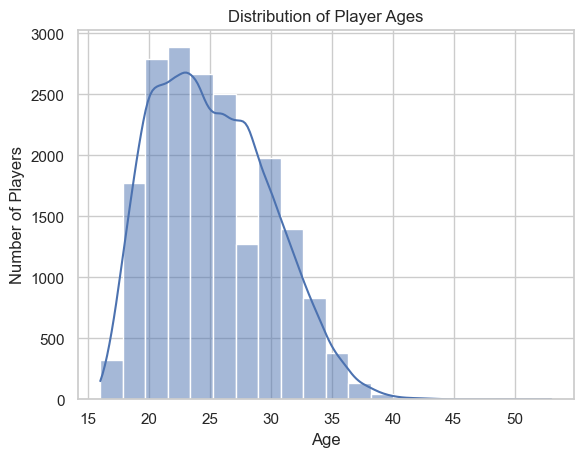

In [72]:
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Distribution of Player Ages')
plt.xlabel('Age')
plt.ylabel('Number of Players')

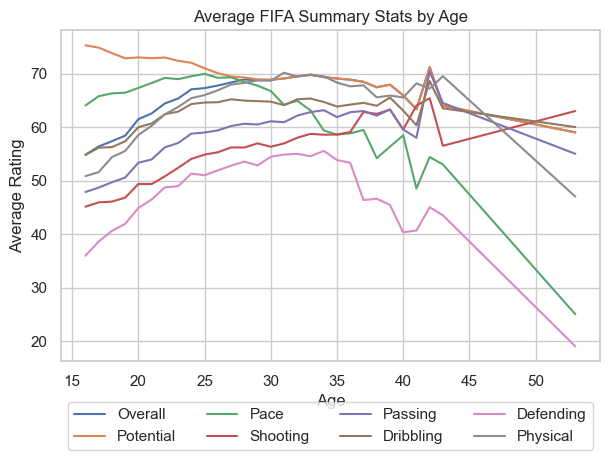

In [73]:

# Select summary stats along with Age
age_stats = df[['Age', 'OVA', 'POT', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY']].dropna()

# Group by age and compute mean per age
age_groups = age_stats.groupby('Age').mean().reset_index()

# Plot average values by age
sns.lineplot(data=age_groups, x='Age', y='OVA', label='Overall')
sns.lineplot(data=age_groups, x='Age', y='POT', label='Potential')
sns.lineplot(data=age_groups, x='Age', y='PAC', label='Pace')
sns.lineplot(data=age_groups, x='Age', y='SHO', label='Shooting')
sns.lineplot(data=age_groups, x='Age', y='PAS', label='Passing')
sns.lineplot(data=age_groups, x='Age', y='DRI', label='Dribbling')
sns.lineplot(data=age_groups, x='Age', y='DEF', label='Defending')
sns.lineplot(data=age_groups, x='Age', y='PHY', label='Physical')

plt.title("Average FIFA Summary Stats by Age")
plt.xlabel("Age")
plt.ylabel("Average Rating")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4)
plt.grid(True)
plt.tight_layout()
plt.show()



In [74]:
# Define high and low potential groups
df['Potential Group'] = df['POT'].apply(lambda x: 'High' if x >= 85 else ('Low' if x <= 70 else 'Mid'))

# Optional: Keep only High and Low for clearer comparison
potential_df = df[df['Potential Group'].isin(['High', 'Low'])]

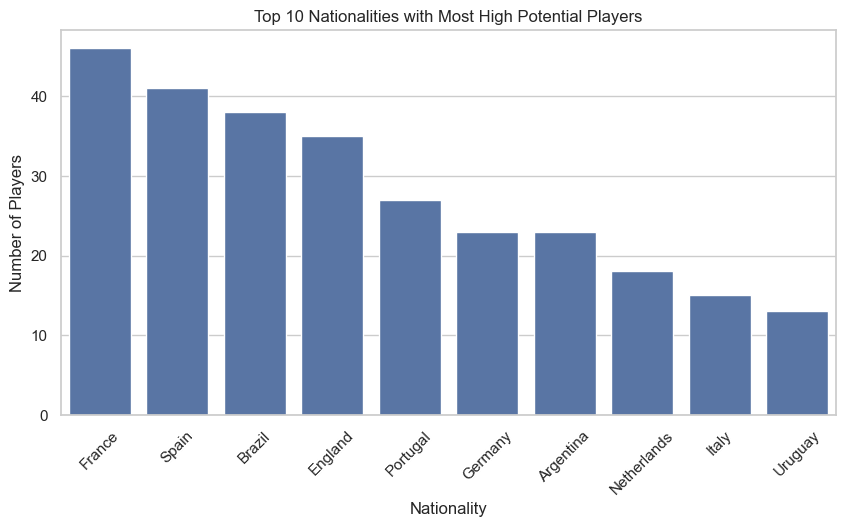

In [75]:
top_nationalities = df[df['Potential Group'] == 'High']['Nationality'].value_counts().nlargest(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_nationalities.index, y=top_nationalities.values)
plt.title("Top 10 Nationalities with Most High Potential Players")
plt.ylabel("Number of Players")
plt.xticks(rotation=45)
plt.show()


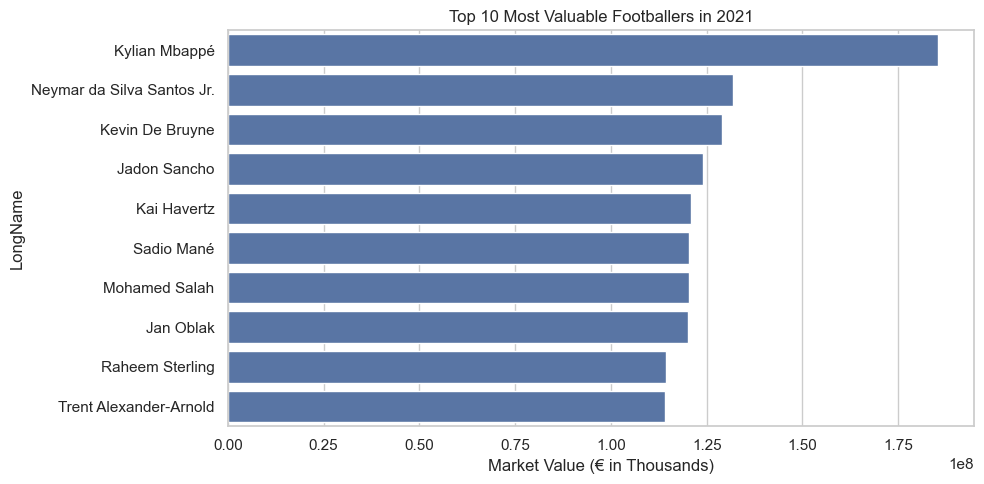

In [76]:
# Select relevant columns
players = df[["LongName", "Value"]]

# Sort players by market value (highest first)
players = players.sort_values(by="Value", ascending=False)

# Get top 10 players
top_10_players = players.head(10)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x=top_10_players["Value"], y=top_10_players["LongName"])

plt.xlabel("Market Value (€ in Thousands)")
plt.title("Top 10 Most Valuable Footballers in 2021")
plt.tight_layout()
plt.show()


In [77]:
# Sort by Value and select top N (e.g., top 100)
top_n = 100
top_players = df.sort_values(by='Value', ascending=False).head(top_n)

# All others (rest of dataset, excluding top N)
other_players = df.drop(top_players.index)


In [78]:
attributes = [ 'OVA', 'POT', 'Attacking', 'Crossing', 'Finishing', 'Short Passing', 
              'Dribbling', 'Long Passing', 'Ball Control', 'Acceleration', 'Sprint Speed', 
              'Agility', 'Reactions', 'Balance', 'Strength', 'Long Shots', 'Mentality', 'Aggression', 
              'Interceptions', 'Positioning', 'Vision', 'Composure']


In [79]:
# Average stats of top vs other players
top_avg = top_players[attributes].mean()
others_avg = other_players[attributes].mean()

# Combine into one DataFrame for comparison
comparison_df = pd.DataFrame({
    'Top Valued Players': top_avg,
    'Other Players': others_avg
})

comparison_df

,Top Valued Players,Other Players
OVA,85.93,65.611579
POT,88.71,71.043329
Attacking,349.26,248.406748
Crossing,69.17,49.585200
Finishing,69.11,45.719159
Short Passing,80.07,58.655278
Dribbling,77.46,55.471635
Long Passing,73.84,52.613539
Ball Control,80.67,58.411092
Acceleration,76.75,64.291912


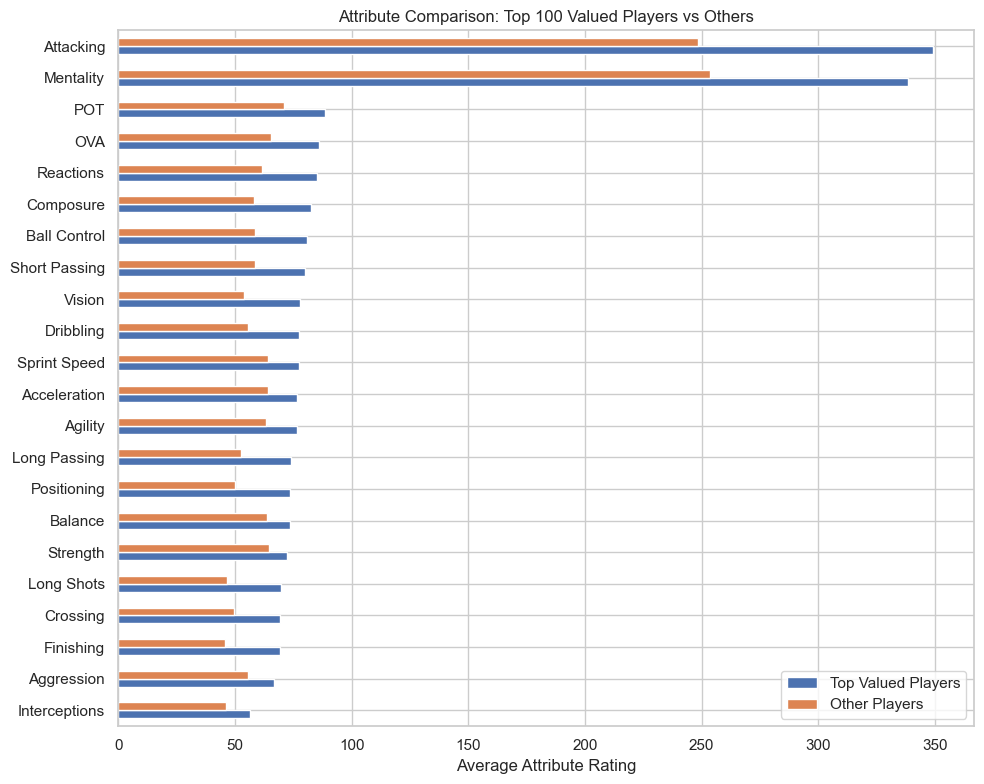

In [80]:
# Plot bar chart comparison
comparison_df.sort_values('Top Valued Players', ascending=True).plot(kind='barh', figsize=(10, 8))
plt.title("Attribute Comparison: Top 100 Valued Players vs Others")
plt.xlabel("Average Attribute Rating")
plt.tight_layout()
plt.show()


In [81]:
# Checking the correlation between player attributes and market value
relevant_columns = ['Value', 'OVA', 'POT', 'Attacking', 'Crossing', 'Finishing', 
                    'Short Passing', 'Dribbling', 'Long Passing', 'Ball Control', 'Acceleration', 'Sprint Speed', 
                    'Agility', 'Reactions', 'Balance', 'Strength', 'Long Shots', 'Mentality', 'Aggression', 'Interceptions', 
                    'Positioning', 'Vision', 'Composure' , 'Age']

# Creating a new dataframe with relevant columns
correlation_df = df[relevant_columns]

# Calculating the correlation matrix
correlation_matrix = correlation_df.corr()

### EDA #1: How do Overall Rating (OVA) and Potential (POT) correlate with Market Value?

            OVA       POT     Value
OVA    1.000000  0.632166  0.552903
POT    0.632166  1.000000  0.528200
Value  0.552903  0.528200  1.000000


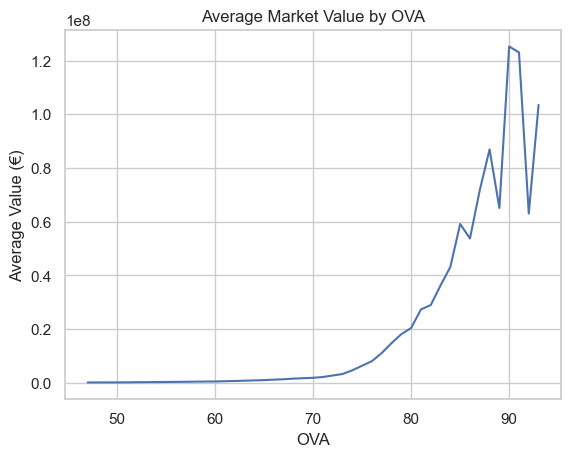

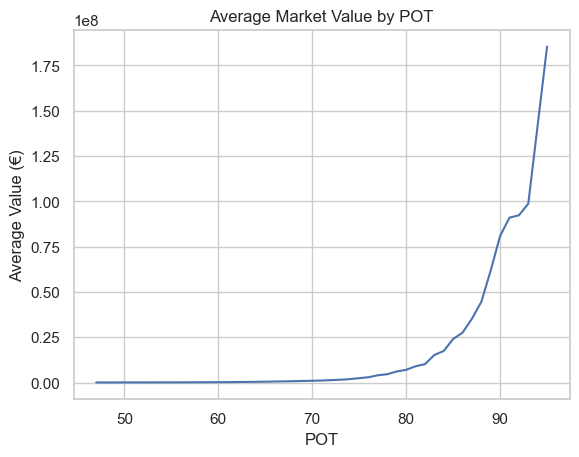

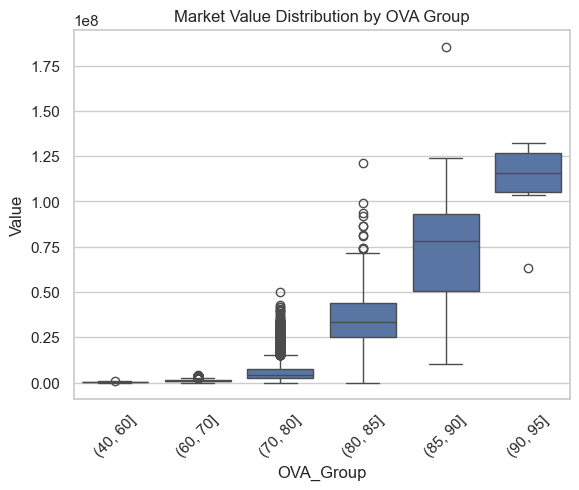

In [82]:
# Correlation matrix
print(df[['OVA', 'POT', 'Value']].corr())

# Line plot: average Value by OVA
df.groupby('OVA')['Value'].mean().plot(kind='line', title='Average Market Value by OVA')
plt.ylabel('Average Value (€)')
plt.show()

# Line plot: average Value by POT
df.groupby('POT')['Value'].mean().plot(kind='line', title='Average Market Value by POT')
plt.ylabel('Average Value (€)')
plt.show()

df['OVA_Group'] = pd.cut(df['OVA'], bins=[40, 60, 70, 80, 85, 90, 95])
df.groupby('OVA_Group', observed=True)['Value'].describe()

sns.boxplot(x='OVA_Group', y='Value', data=df)
plt.title('Market Value Distribution by OVA Group')
plt.xticks(rotation=45)
plt.show()

C:\Users\Simon\AppData\Local\Temp\ipykernel_2692\1320153136.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['Log_Value'] = np.log1p(filtered_df['Value'])


<Figure size 1400x600 with 0 Axes>

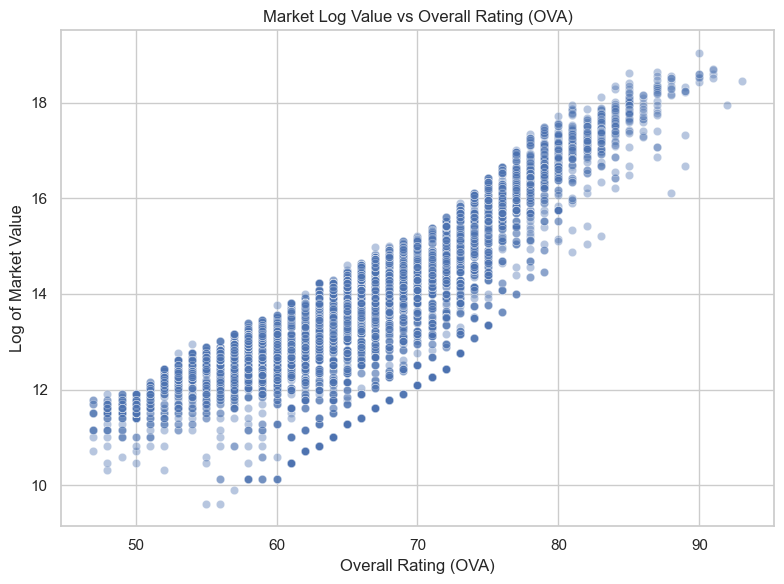

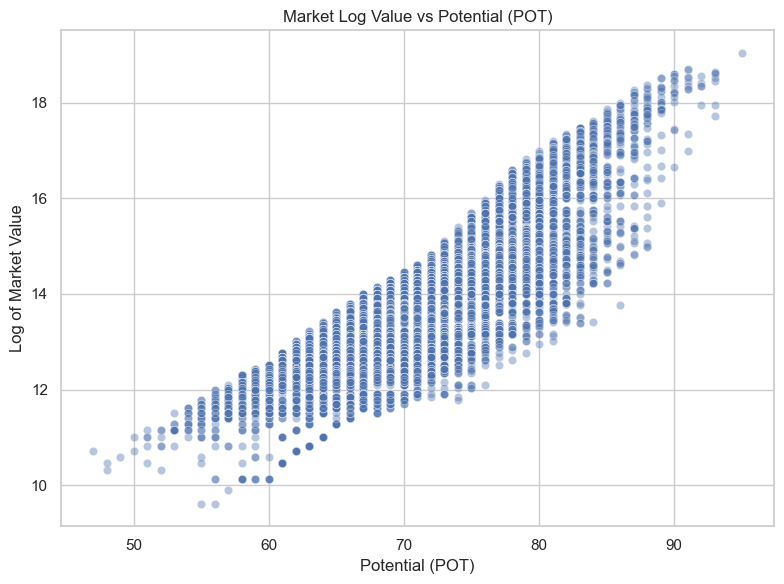

(np.float64(0.8909880032273788), np.float64(0.825841178564725))

In [83]:
# Calculating correlation coefficients
# Remove bottom 1% of Value before computing log
filtered_df = correlation_df[correlation_df['Value'] > correlation_df['Value'].quantile(0.01)]

# Recompute Log_Value on the filtered data
filtered_df['Log_Value'] = np.log1p(filtered_df['Value'])

correlation_ova = df['OVA'].corr(filtered_df['Log_Value'])
correlation_pot = df['POT'].corr(filtered_df['Log_Value'])

plt.figure(figsize=(14, 6))

# Scatter plot for OVA vs Market Value (Log)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='OVA', y='Log_Value', data=filtered_df, alpha=0.4)
plt.title('Market Log Value vs Overall Rating (OVA)')
plt.xlabel('Overall Rating (OVA)')
plt.ylabel('Log of Market Value')
plt.tight_layout()
plt.show()

# Scatter plot for POT vs Market Value (Log)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='POT', y='Log_Value', data=filtered_df, alpha=0.4)
plt.title('Market Log Value vs Potential (POT)')
plt.xlabel('Potential (POT)')
plt.ylabel('Log of Market Value')
plt.tight_layout()
plt.show()

# Returning the correlation coefficients
correlation_ova, correlation_pot

The correlation coefficients calculated are as follows:

Correlation between OVA and Market Value: 0.8909
Correlation between POT and Market Value: 0.8259
These values indicate a strong positive correlation between both OVA and POT with Market Value, suggesting that as a player's overall rating and potential increase, their market value tends to increase as well.

In [84]:
# Filter just the 70–80 OVA group
mid_ova_df = df[(df['OVA'] >= 70) & (df['OVA'] <= 80)]

# Sort by Value descending
mid_ova_df.sort_values(by='Value', ascending=False).head(20)

,ID,Name,LongName,Nationality,Age,OVA,POT,Club,Contract,Positions,Height,Weight in kg,Preferred Foot,BOV,Best Position,Joined,Value,Wage,Release Clause,Attacking,Crossing,Finishing,Heading Accuracy,Short Passing,Volleys,Skill,Dribbling,Curve,FK Accuracy,Long Passing,Ball Control,Movement,Acceleration,Sprint Speed,Agility,Reactions,Balance,Power,Shot Power,Jumping,Stamina,Strength,Long Shots,Mentality,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Defending,Marking,Standing Tackle,Sliding Tackle,Goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total Stats,Base Stats,W/F,SM,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Log_Weight,Contract_Type,Position_List,Primary_Position,Position_Group,Position_Count,Log_Value,Potential Group,OVA_Group
370,238794,Vinícius Jr.,Vinícius José de Oliveira Júnior,Brazil,19,80,93,Real Madrid,2018 ~ 2025,LW,176.0,73.0,Right,81,RM,2018-07-12,50000000.0,95000.0,€73.6M,331,71,68,50,72,70,379,88,77,62,67,85,441,95,95,94,75,82,357,73,75,79,62,68,297,58,26,75,73,65,74,75,32,25,18,36,5,7,7,7,10,1916,417,4,5,High,Medium,2,95,69,71,87,29,66,4.290459,Fixed Contract,[LW],LW,Forward,1,17.727534,High,"(70, 80]"
389,233064,M. Mount,Mason Mount,England,21,80,87,Chelsea,2016 ~ 2024,"CAM, CM, LW",178.0,70.0,Right,82,CAM,2016-01-10,43000000.0,70000.0,€44.1M,356,77,78,59,81,61,396,79,79,82,74,82,383,78,70,79,80,76,337,78,50,78,52,79,334,66,48,79,81,60,77,132,45,53,34,56,11,12,13,8,12,1994,419,4,3,High,Medium,1,74,77,79,80,48,61,4.248495,Fixed Contract,"[CAM, CM, LW]",CAM,Midfielder,3,17.576711,High,"(70, 80]"
410,224232,N. Barella,Nicolò Barella,Italy,23,80,87,Inter,2020 ~ 2024,"CM, CAM",172.0,68.0,Right,82,CM,2020-09-01,42000000.0,86000.0,€39M,326,76,63,40,82,65,386,83,75,67,78,83,396,80,76,78,79,83,349,72,62,87,62,66,388,82,79,75,79,73,80,233,75,80,78,54,11,5,13,14,11,2132,452,3,3,Medium,High,2,78,67,79,82,74,72,4.219508,Fixed Contract,"[CM, CAM]",CM,Midfielder,2,17.553180,High,"(70, 80]"
381,235569,T. Ndombele,Tanguy Ndombele,France,23,80,87,Tottenham Hotspur,2019 ~ 2024,"CM, CDM",181.0,76.0,Right,82,CAM,2019-07-02,42000000.0,82000.0,€43.1M,327,69,59,56,84,59,394,88,74,65,81,86,400,79,69,84,82,86,345,80,60,58,79,68,363,75,72,69,87,60,87,208,66,73,69,46,8,10,13,8,7,2083,448,3,4,Medium,Medium,1,74,66,80,87,69,72,4.330733,Fixed Contract,"[CM, CDM]",CM,Midfielder,2,17.553180,High,"(70, 80]"
402,226166,N. Mukiele,Nordi Mukiele,France,22,80,87,RB Leipzig,2018 ~ 2023,"RB, CB, RWB",187.0,84.0,Right,81,CB,2018-07-01,40500000.0,46000.0,€35.2M,286,74,30,74,73,35,319,73,69,33,70,74,370,77,87,68,73,65,353,57,90,75,79,52,323,72,83,59,64,45,72,242,75,85,82,57,10,7,14,11,15,1950,423,3,3,Medium,Medium,1,83,42,69,72,80,77,4.430817,Fixed Contract,"[RB, CB, RWB]",RB,Defender,3,17.516813,High,"(70, 80]"
387,240130,Éder Militão,Éder Gabriel Militão,Brazil,22,80,87,Real Madrid,2019 ~ 2025,"CB, RB",186.0,78.0,Right,82,CB,2019-07-01,40000000.0,115000.0,€42.8M,301,72,48,77,70,34,310,70,60,40,69,71,373,77,79,69,81,67,351,62,85,85,77,42,348,83,82,64,59,60,74,244,81,82,81,61,11,8,15,12,15,1988,427,2,2,Medium,High,1,78,50,66,71,81,81,4.356709,Fixed Contract,"[CB, RB]",CB,Defender,2,17.504390,High,"(70, 80]"
536,232293,V. Osimhen,Victor Osimhen,Nigeria,21,79,87,Napoli,2020 ~ 2025,ST,185.0,78.0,Right,80,ST,2020-09-01,39500000.0,54000.0,€36.1M,367,64,83,78,67,75,309,70,63,48,53,75,396,81,92,77,78,68,395,78,82,86,77,72,331,76,34,81,65,75,72,93,36,38,19,53,14,14,10,9,6,1944,420,4,3,High,High,1,87,79,63,73,39,79,4.356709,Fixed Contract,[ST],ST,Forward,1,17.491811,High,"(70, 80]"
513,244260,Dani Olmo,Daniel Olmo Carvajal,Spain,22,79,87,RB Leipzig,2020 ~ 2024,"CAM, LM, RM",179.0,72.0,Right,81,CAM,2020-01-25,39500000.0,48000.0,€35.2M,349,77,75,43,78,76,390,83,72,75,77,83,379,77,60,80,76,86,343,79,55,79,54,76,332,51,57,80,78,66,82,144,50,50,44,66,15,15,13,12,11,2003,414,4,4,High,Medium,1,68,76,77,83,50,60,4.276666,Fixed Contract,"[CAM, LM, RM]",CAM,Midfielder,3,17.491811,High,"(70, 80]"
522,237692,P. Foden,Phil Foden,England,

In [85]:
mid_ova_df = df[(df['OVA'] >= 70) & (df['OVA'] <= 80)]

Q1 = mid_ova_df['Value'].quantile(0.25)
Q3 = mid_ova_df['Value'].quantile(0.75)
IQR = Q3 - Q1

threshold_value = Q3 + 1.5 * IQR
print("Outlier threshold value:", threshold_value)

Outlier threshold value: 13400000.0


In [86]:
mid_ova_df.loc[mid_ova_df['Value'] > threshold_value]

,ID,Name,LongName,Nationality,Age,OVA,POT,Club,Contract,Positions,Height,Weight in kg,Preferred Foot,BOV,Best Position,Joined,Value,Wage,Release Clause,Attacking,Crossing,Finishing,Heading Accuracy,Short Passing,Volleys,Skill,Dribbling,Curve,FK Accuracy,Long Passing,Ball Control,Movement,Acceleration,Sprint Speed,Agility,Reactions,Balance,Power,Shot Power,Jumping,Stamina,Strength,Long Shots,Mentality,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Defending,Marking,Standing Tackle,Sliding Tackle,Goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total Stats,Base Stats,W/F,SM,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Log_Weight,Contract_Type,Position_List,Primary_Position,Position_Group,Position_Count,Log_Value,Potential Group,OVA_Group
370,238794,Vinícius Jr.,Vinícius José de Oliveira Júnior,Brazil,19,80,93,Real Madrid,2018 ~ 2025,LW,176.0,73.0,Right,81,RM,2018-07-12,50000000.0,95000.0,€73.6M,331,71,68,50,72,70,379,88,77,62,67,85,441,95,95,94,75,82,357,73,75,79,62,68,297,58,26,75,73,65,74,75,32,25,18,36,5,7,7,7,10,1916,417,4,5,High,Medium,2,95,69,71,87,29,66,4.290459,Fixed Contract,[LW],LW,Forward,1,17.727534,High,"(70, 80]"
371,239207,M. Gómez,Maximiliano Gómez,Uruguay,23,80,85,Valencia CF,2019 ~ 2024,ST,186.0,84.0,Right,82,ST,2019-07-14,32000000.0,40000.0,€43.5M,378,59,84,87,73,75,345,72,75,57,64,77,342,67,68,67,80,60,404,81,83,79,87,74,324,74,21,87,70,72,82,78,35,20,23,46,7,8,13,12,6,1917,404,3,3,High,Low,1,68,81,68,73,32,82,4.430817,Fixed Contract,[ST],ST,Forward,1,17.281246,High,"(70, 80]"
372,241671,D. Livaković,Dominik Livaković,Croatia,25,80,85,Dinamo Zagreb,2015 ~ 2023,GK,187.0,79.0,Right,80,GK,2015-08-31,24500000.0,900.0,€33M,94,13,12,13,46,10,126,19,12,11,56,28,286,57,54,65,80,30,233,56,61,32,75,9,133,26,21,11,60,15,64,65,24,20,21,393,80,78,74,79,82,1330,448,3,1,Medium,Medium,1,80,78,74,82,55,79,4.369448,Fixed Contract,[GK],GK,Goalkeeper,1,17.014184,High,"(70, 80]"
373,244369,V. Tsygankov,Viktor Tsygankov,Ukraine,22,80,86,Dynamo Kyiv,2015 ~ 2023,RM,175.0,71.0,Left,81,CAM,2015-01-01,34000000.0,1000.0,€49.2M,345,77,75,45,80,68,382,80,72,76,73,81,402,84,85,82,78,73,317,70,50,74,49,74,324,57,39,75,80,73,76,135,62,36,37,49,9,7,15,6,12,1954,418,4,4,High,Medium,1,85,73,78,80,45,57,4.262680,Fixed Contract,[RM],RM,Midfielder,1,17.341871,High,"(70, 80]"
381,235569,T. Ndombele,Tanguy Ndombele,France,23,80,87,Tottenham Hotspur,2019 ~ 2024,"CM, CDM",181.0,76.0,Right,82,CAM,2019-07-02,42000000.0,82000.0,€43.1M,327,69,59,56,84,59,394,88,74,65,81,86,400,79,69,84,82,86,345,80,60,58,79,68,363,75,72,69,87,60,87,208,66,73,69,46,8,10,13,8,7,2083,448,3,4,Medium,Medium,1,74,66,80,87,69,72,4.330733,Fixed Contract,"[CM, CDM]",CM,Midfielder,2,17.553180,High,"(70, 80]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1654,239956,M. Boadu,Myron Boadu,Netherlands,19,75,87,AZ Alkmaar,2017 ~ 2023,ST,183.0,67.0,Right,77,ST,2017-07-01,13500000.0,7000.0,€19.6M,330,52,80,61,69,68,307,74,62,44,52,75,416,89,87,87,79,74,357,74,80,71,66,66,273,44,23,74,66,66,73,69,29,22,18,55,9,15,14,6,11,1807,391,5,3,High,Low,1,88,74,61,76,28,64,4.204693,Fixed Contract,[ST],ST,Forward,1,16.418200,High,"(70, 80]"
1664,237681,T. Kubo,Takefusa Kubo,Japan,19,75,89,Villarreal CF,"Jun 30, 2021 On Loan","RM, CM, CAM",173.0,67.0,Left,76,CAM,2019-07-01,13500000.0,59000.0,€0,300,61,70,39,73,57,364,85,68,72,58,81,401,89,76,87,65,84,309,66,54,77,52,60,273,43,29,68,72,61,70,131,40,43,48,48,6,7,15,10,10,1826,395,4,4,High,Medium,1,82,66,68,83,39,57,4.204693,Loan,"[RM, CM, CAM]",RM,Midfielder,3,16.418200,High,"(70, 80]"
1752,246646,M. Caqueret,Maxence Caqueret,France,20,75,87,Olympique Lyonnais,2018 ~ 2023,"CM, CDM",174.0,63.0,Right,77,CM,2018-12-14,13500000.0,37000.0,€25.2M,278

In [87]:
high_ova_df = df[(df['OVA'] >= 80) & (df['OVA'] <= 90)]
high_ova_df.sort_values(by='Value', ascending=False).head(10)

,ID,Name,LongName,Nationality,Age,OVA,POT,Club,Contract,Positions,Height,Weight in kg,Preferred Foot,BOV,Best Position,Joined,Value,Wage,Release Clause,Attacking,Crossing,Finishing,Heading Accuracy,Short Passing,Volleys,Skill,Dribbling,Curve,FK Accuracy,Long Passing,Ball Control,Movement,Acceleration,Sprint Speed,Agility,Reactions,Balance,Power,Shot Power,Jumping,Stamina,Strength,Long Shots,Mentality,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Defending,Marking,Standing Tackle,Sliding Tackle,Goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total Stats,Base Stats,W/F,SM,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Log_Weight,Contract_Type,Position_List,Primary_Position,Position_Group,Position_Count,Log_Value,Potential Group,OVA_Group
8,231747,K. Mbappé,Kylian Mbappé,France,21,90,95,Paris Saint-Germain,2018 ~ 2022,"ST, LW, RW",178.0,73.0,Right,91,ST,2018-07-01,185500000.0,160000.0,€203.1M,408,78,91,73,83,83,394,92,79,63,70,90,458,96,96,92,92,82,404,86,77,86,76,79,341,62,38,91,80,70,84,100,34,34,32,42,13,5,7,11,6,2147,466,4,5,High,Low,3,96,86,78,91,39,76,4.290459,Fixed Contract,"[ST, LW, RW]",ST,Forward,3,19.038565,High,"(85, 90]"
29,233049,J. Sancho,Jadon Sancho,England,20,87,93,Borussia Dortmund,2017 ~ 2023,"RM, LM, CAM",180.0,76.0,Right,89,CAM,2017-08-31,124000000.0,82000.0,€132.1M,373,83,81,38,88,83,380,92,81,48,68,91,435,86,81,91,87,90,328,70,51,77,67,63,313,44,39,83,87,60,84,105,32,41,32,52,7,11,10,11,13,1986,430,3,5,High,Medium,3,83,74,81,91,37,64,4.330733,Fixed Contract,"[RM, LM, CAM]",RM,Midfielder,3,18.635792,High,"(85, 90]"
65,235790,K. Havertz,Kai Havertz,Germany,21,85,93,Chelsea,2020 ~ 2025,"CAM, RM, CF",188.0,83.0,Left,87,CAM,2020-09-04,121000000.0,105000.0,€119.7M,400,73,85,78,84,80,388,86,84,53,78,87,403,78,88,78,85,74,378,74,75,82,69,78,319,42,38,84,82,73,84,123,39,46,38,47,6,8,11,10,12,2058,441,4,4,Medium,Medium,3,84,81,79,85,45,67,4.418841,Fixed Contract,"[CAM, RM, CF]",CAM,Midfielder,3,18.611301,High,"(80, 85]"
11,208722,S. Mané,Sadio Mané,Senegal,28,90,90,Liverpool,2016 ~ 2023,LW,175.0,69.0,Right,90,LW,2016-07-01,120500000.0,250000.0,€144.3M,410,76,90,84,85,75,391,91,76,64,71,89,460,95,93,93,93,86,406,84,86,88,70,78,358,75,35,92,85,71,84,122,42,42,38,56,10,10,15,7,14,2203,469,4,4,High,Medium,3,94,85,80,90,44,76,4.234107,Fixed Contract,[LW],LW,Forward,1,18.607160,High,"(85, 90]"
6,209331,M. Salah,Mohamed Salah,Egypt,28,90,90,Liverpool,2017 ~ 2023,RW,175.0,71.0,Left,90,RW,2017-07-01,120500000.0,250000.0,€144.3M,392,79,91,59,84,79,406,90,83,69,75,89,460,94,92,91,92,91,393,80,69,85,75,84,376,63,55,91,84,83,90,122,38,43,41,62,14,14,9,11,14,2211,470,3,4,High,Medium,3,93,86,81,90,45,75,4.262680,Fixed Contract,[RW],RW,Forward,1,18.607160,High,"(85, 90]"
18,202652,R. Sterling,Raheem Sterling,England,25,88,90,Manchester City,2015 ~ 2023,"LW, RW",170.0,69.0,Right,88,LW,2015-07-14,114500000.0,270000.0,€139.6M,360,78,85,46,84,67,387,90,77,63,69,88,464,96,90,94,90,94,358,78,57,79,65,79,332,59,30,92,82,69,80,147,47,53,47,63,15,12,12,15,9,2111,455,3,4,High,Medium,3,93,81,79,90,45,67,4.234107,Fixed Contract,"[LW, RW]",LW,Forward,2,18.556085,High,"(85, 90]"
30,231281,T. Alexander-Arnold,Trent Alexander-Arnold,England,21,87,92,Liverpool,2015 ~ 2024,RB,180.0,69.0,Right,87,RB,2015-10-07,114000000.0,110000.0,€115.5M,365,93,56,69,85,62,426,77,88,85,89,87,391,77,83,74,83,74,370,80,66,88,62,74,371,74,82,76,84,55,81,241,79,83,79,56,14,15,14,6,7,2220,464,4,3,High,Medium,2,80,66,87,80,80,71,4.234107,Fixed Contract,[RB],RB,Defender,1,18.551709,High,"(85, 90]"
10,203376,V. van Dijk,Virgil van Dijk,Netherlands,28,90,91,Liverpool,2018 ~ 2023,CB,193.0,92.0,Right,90,CB,2018-01-01,113000000.0,210000.0,€145.3M,316,53,52,87,79,45,363,70,60,70,86,77,354,72,79,61,89,53,402,81,90,75,92,64,347,83,90,47,65,62,90,272,93,93,86,58,13,10,13,11,11,2112,455,3,2,Medium,Medium,3,76,60,71,71,91,86,4.521789,Fixed Contract,[CB],CB,Defender,1,18.542898,High,"(85, 90]"
9,192448,M. ter Stegen,Marc-André ter Stegen,Germany,28,90,93,

Text(0.5, 1.0, 'Market Value vs OVA (Outliers Highlighted)')

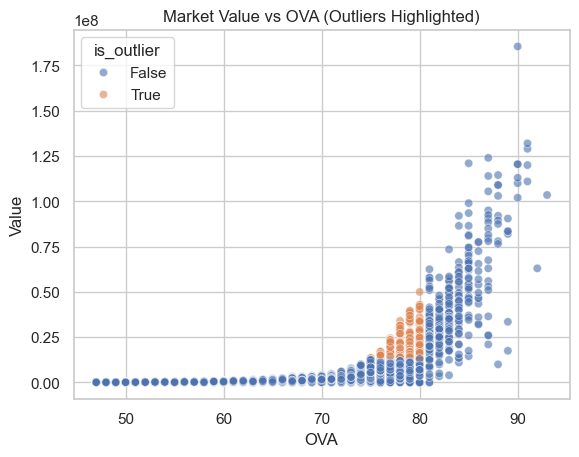

In [88]:
# Add a column marking outliers
df['is_outlier'] = (df['OVA'].between(70, 80)) & (df['Value'] > threshold_value)

# Plot with color
sns.scatterplot(data=df, x='OVA', y='Value', hue='is_outlier', alpha=0.6)
plt.title('Market Value vs OVA (Outliers Highlighted)')

### EDA #2 What is the impact of Age in response to OVA and Market Value

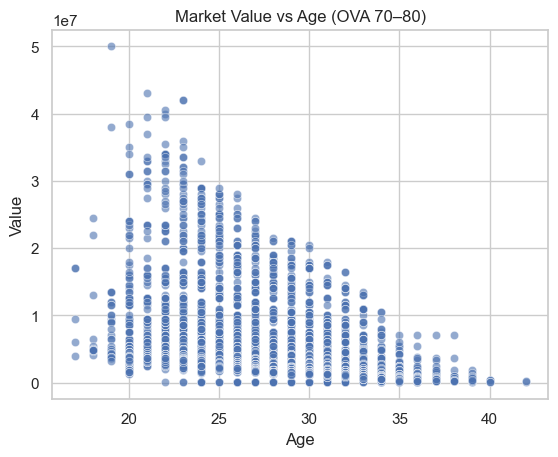

In [89]:
filtered_df = df[(df['OVA'] >= 70) & (df['OVA'] <= 80)]

sns.scatterplot(data=filtered_df, x='Age', y='Value', alpha=0.6)
plt.title('Market Value vs Age (OVA 70–80)')
plt.show()

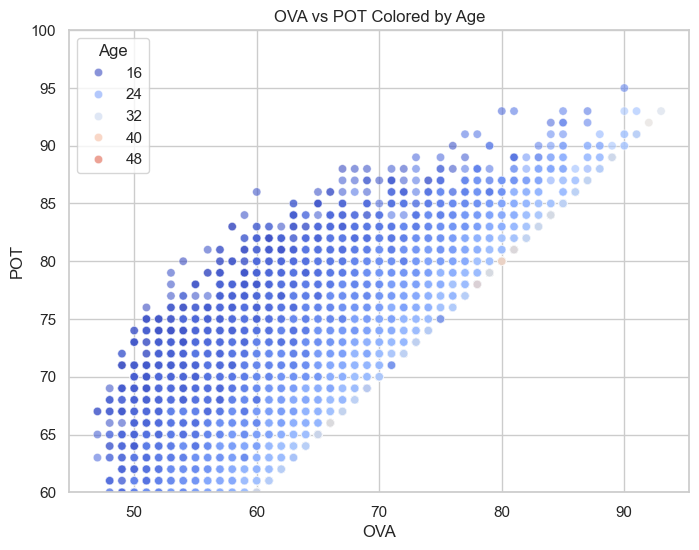

In [90]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='OVA', y='POT', hue='Age', palette='coolwarm', alpha=0.6)
plt.title('OVA vs POT Colored by Age')
plt.ylim(60, 100)
plt.show()

EDA #3 Is there a relationship between a player’s potential and market value?

### EDA #3.1 Which individual player attributes have the strongest linear correlation with market value in FIFA 21?

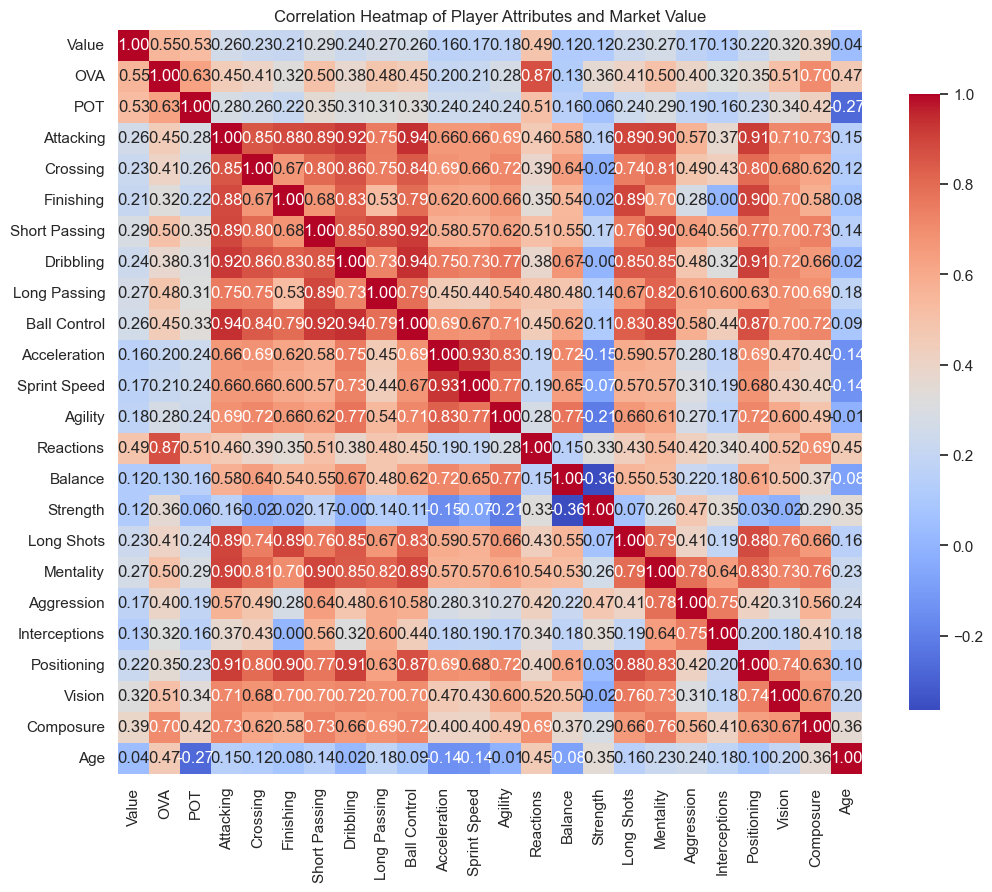

In [91]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar_kws={'shrink': .8})
plt.title('Correlation Heatmap of Player Attributes and Market Value')
plt.show()

The heatmap displays pairwise Pearson correlation coefficients between FIFA 21 player attributes and market value.

- Value (market value) has moderate correlation with:

- OVA (Overall rating): ~0.55

- POT (Potential): ~0.53

- Composure: ~0.43

- Positioning: ~0.42

- Vision: ~0.39

- Most technical skills (e.g., Dribbling, Ball Control, Short Passing) show weak to moderate correlation with Value.

- Physical attributes like Strength and Balance have low or negligible correlation with market value.

- Goalkeeping attributes were excluded or show near-zero correlation for outfield players.

- High inter-correlation is visible between grouped skill sets (e.g., Dribbling and Ball Control > 0.85), confirming that many skills cluster together logically.





### EDA #3.2 Which attributes most strongly predict a player's market value in FIFA 21, when analyzed per position group?

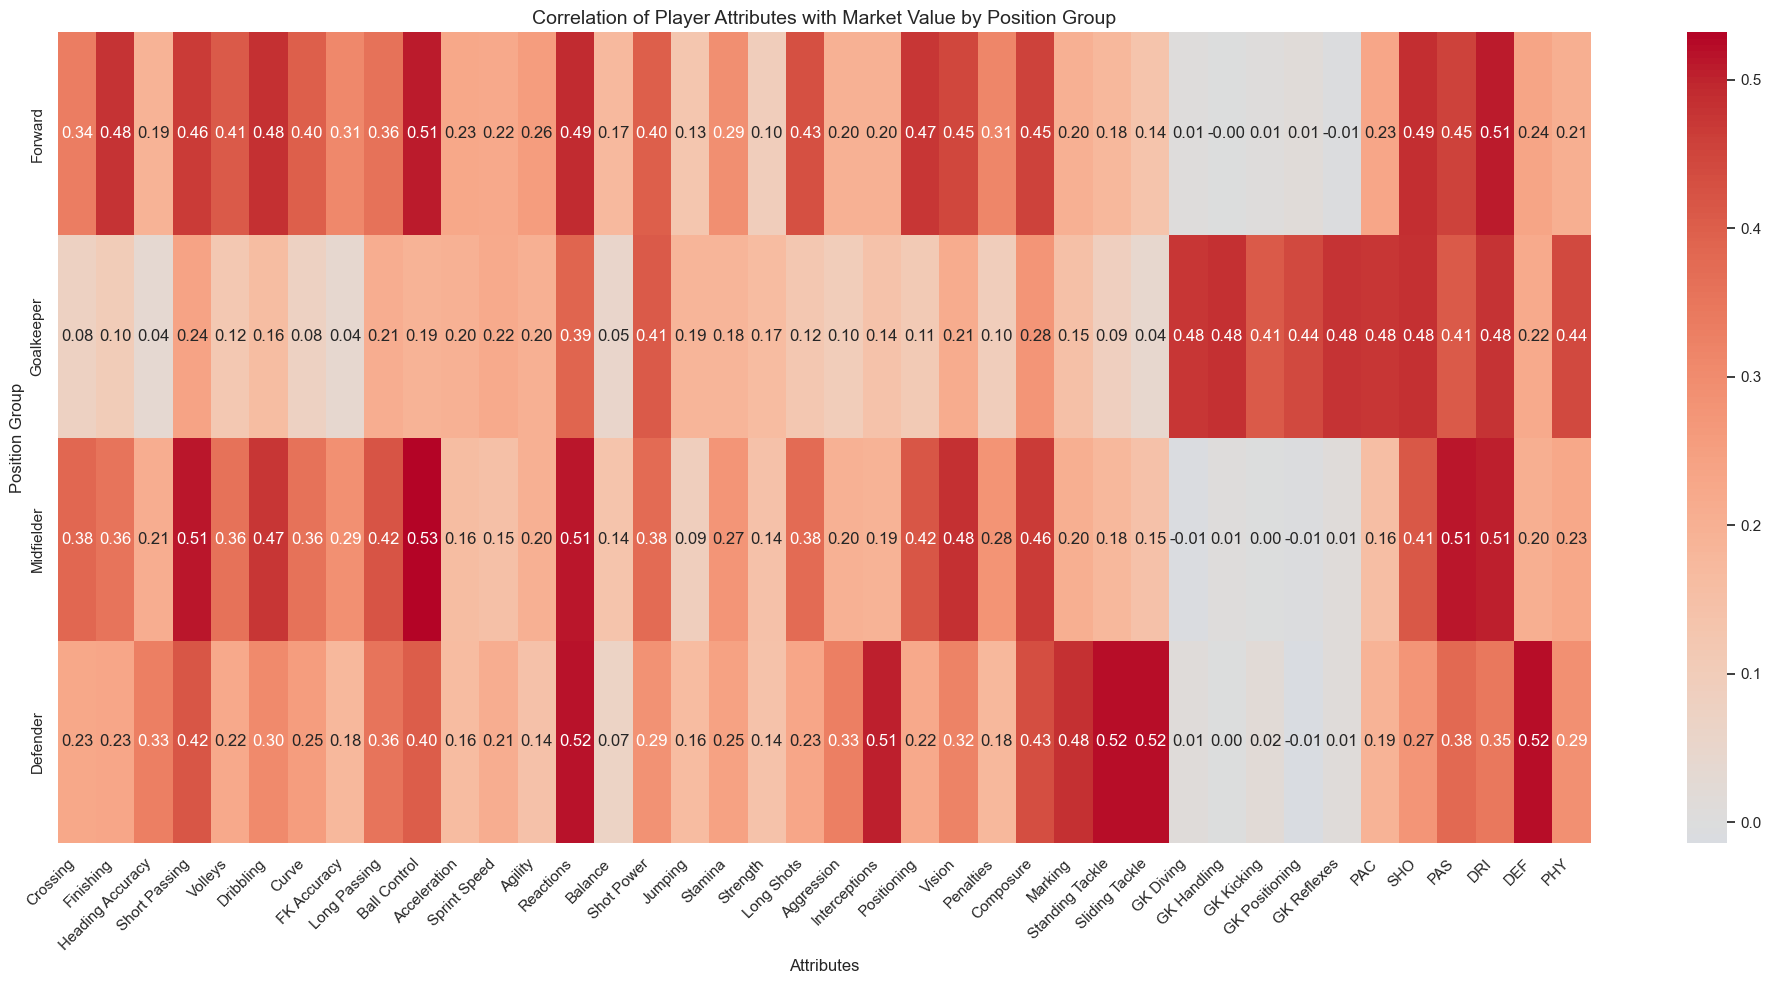

In [92]:
# Define attribute categories
attributes = [
    # Attacking
    'Crossing', 'Finishing', 'Heading Accuracy', 'Short Passing', 'Volleys',
    
    # Skill
    'Dribbling', 'Curve', 'FK Accuracy', 'Long Passing', 'Ball Control',
    
    # Movement
    'Acceleration', 'Sprint Speed', 'Agility', 'Reactions', 'Balance',
    
    # Power
    'Shot Power', 'Jumping', 'Stamina', 'Strength', 'Long Shots',
    
    # Mentality
    'Aggression', 'Interceptions', 'Positioning', 'Vision', 'Penalties', 'Composure',
    
    # Defending
    'Marking', 'Standing Tackle', 'Sliding Tackle',
    
    # Goalkeeping (optional for GK analysis)
    'GK Diving', 'GK Handling', 'GK Kicking', 'GK Positioning', 'GK Reflexes',
    
    # Summary Stats
    'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY'
]

# Initialize container for correlations by position group
position_corrs = {}

# Loop through each position group to compute attribute correlations with 'Value'
for position in df['Position_Group'].dropna().unique():
    subset = df[df['Position_Group'] == position]
    
    # Filter out only attributes that are available in the dataset
    valid_attrs = [attr for attr in attributes if attr in subset.columns]
    
    # Drop rows with missing data in relevant columns
    filtered = subset[valid_attrs + ['Value']].dropna()
    
    # Compute correlations with 'Value'
    corr = filtered.corr(numeric_only=True)['Value'].drop('Value')
    position_corrs[position] = corr

position_corr_df = pd.DataFrame(position_corrs).T

# Heatmap visualization
plt.figure(figsize=(20, 10))
sns.heatmap(position_corr_df, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Correlation of Player Attributes with Market Value by Position Group", fontsize=14)
plt.xlabel("Attributes")
plt.ylabel("Position Group")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Correlation of Player Attributes with Market Value by Position Group

## FORWARDS – Key Drivers of Market Value

| Attribute       | Correlation |
|----------------|-------------|
| Ball Control    | 0.5105      |
| Reactions       | 0.4925      |
| Dribbling       | 0.4828      |
| Finishing       | 0.4785      |
| Short Passing   | 0.4642      |
| Vision          | 0.4743      |
| DRI (Dribbling) | 0.5069      |
| SHO (Shooting)  | 0.4875      |

**Insights:**
- Forward market value is driven by offensive technical attributes.
- High-value forwards tend to have strong vision and passing, indicating playmaking ability.
- Physical traits like strength and aggression have lower correlations (< 0.30).

---

## MIDFIELDERS – Key Drivers of Market Value

| Attribute        | Correlation |
|------------------|-------------|
| Ball Control      | 0.5320      |
| Reactions         | 0.5135      |
| Short Passing     | 0.5113      |
| DRI (Dribbling)   | 0.5052      |
| PAS (Passing)     | 0.5126      |
| Vision            | 0.4821      |
| Composure         | 0.4646      |
| Dribbling         | 0.4749      |

**Insights:**
- Midfielders require a wide skill set; passing, control, and vision are most valuable.
- Intelligence-related attributes (Reactions, Composure) significantly impact market value.
- Speed and strength are moderately influential.

---

## DEFENDERS – Key Drivers of Market Value

| Attribute         | Correlation |
|------------------|-------------|
| Sliding Tackle     | 0.5233      |
| Standing Tackle    | 0.5229      |
| DEF (Defending)    | 0.5223      |
| Reactions          | 0.5176      |
| Interceptions      | 0.5064      |
| Marking            | 0.4330      |
| Strength           | 0.2885      |

**Insights:**
- Defensive skills such as tackling and interceptions are the top market drivers.
- Reactions is again a crucial indicator of value.
- Technical control (e.g., ball control, short passing) also plays a moderate role.

---

## GOALKEEPERS – Key Drivers of Market Value

| Attribute        | Correlation |
|------------------|-------------|
| GK Diving         | 0.4760      |
| GK Reflexes       | 0.4768      |
| GK Handling       | 0.4830      |
| GK Positioning    | 0.4437      |
| GK Kicking        | 0.4101      |
| Reactions         | 0.3911      |

**Insights:**
- Market value for goalkeepers is dominated by position-specific GK attributes.
- Reactions remains an important universal attribute.
- Outfield skills like crossing, passing, and tackling are minimally relevant.

---

## UNIVERSAL TRENDS

- **Ball Control** and **Reactions** are consistently among the highest correlated attributes across all positions.
- **Vision**, **Composure**, and **Dribbling** are essential for offensive and midfield players.
- **Defensive-specific** and **GK-specific** attributes are critical only within their respective roles.
- **Physical traits** like Strength and Stamina generally show weaker correlations with market value.


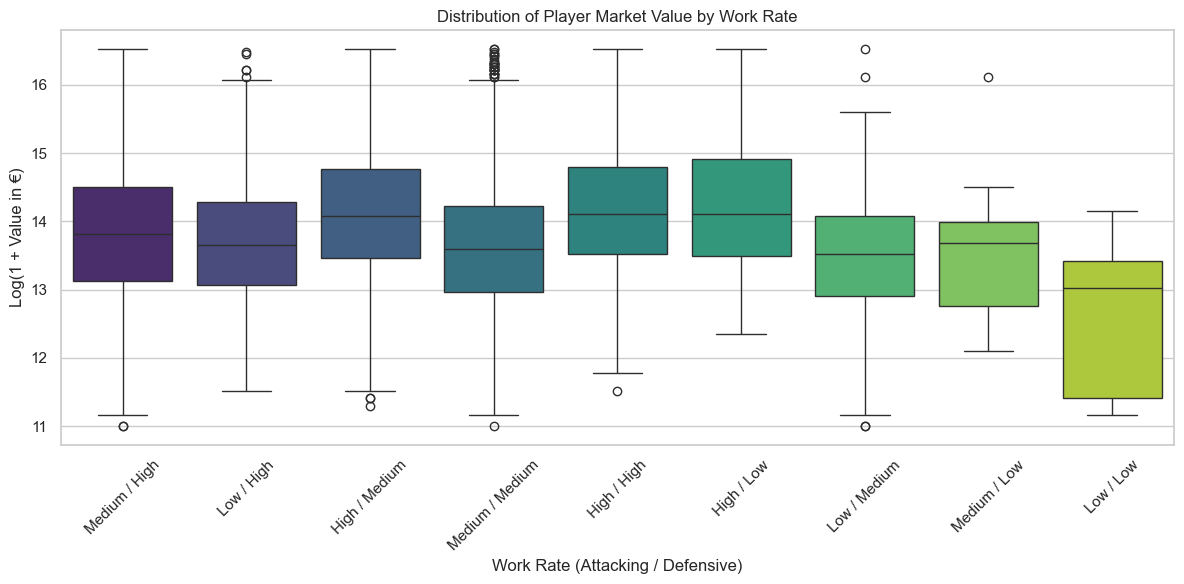


=== Hypothesis Test: ANOVA on Work Rate ===
H₀: The mean player market values (Log_Value) are equal across all Work Rate groups.
H₁: At least one Work Rate group has a significantly different mean Log_Value.

ANOVA Result:
F-statistic: 42.70
P-value: 0.0000
→ Reject H₀: There is a significant difference in mean player value across Work Rate groups.


In [116]:
# Step 1: Construct Work Rate and Clean Data
df['Work_Rate'] = df['A/W'].astype(str) + ' / ' + df['D/W'].astype(str)
df = df.dropna(subset=['Work_Rate', 'Value'])

# Log-transform Value to reduce skewness
df['Log_Value'] = np.log1p(df['Value'])

# Step 2: Remove outliers in Log_Value using IQR
Q1 = df['Log_Value'].quantile(0.25)
Q3 = df['Log_Value'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_filtered = df[(df['Log_Value'] >= lower_bound) & (df['Log_Value'] <= upper_bound)]

# Optional: Filter to most common Work Rates (top 10)
top_rates = df_filtered['Work_Rate'].value_counts().head(10).index
df_filtered = df_filtered[df_filtered['Work_Rate'].isin(top_rates)]

# Step 3: Visualization
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_filtered,
    x='Work_Rate',
    y='Log_Value',
    hue='Work_Rate',
    palette='viridis',
    legend=False  # Disable redundant legend
)
plt.xticks(rotation=45)
plt.title("Distribution of Player Market Value by Work Rate")
plt.xlabel("Work Rate (Attacking / Defensive)")
plt.ylabel("Log(1 + Value in €)")
plt.tight_layout()
plt.show()

# Step 4: ANOVA Test on Filtered Data
print("\n=== Hypothesis Test: ANOVA on Work Rate ===")
print("H₀: The mean player market values (Log_Value) are equal across all Work Rate groups.")
print("H₁: At least one Work Rate group has a significantly different mean Log_Value.")

# Prepare data for ANOVA
grouped = [group['Log_Value'].values for name, group in df_filtered.groupby("Work_Rate")]
anova_result = f_oneway(*grouped)

# ANOVA result
print(f"\nANOVA Result:")
print(f"F-statistic: {anova_result.statistic:.2f}")
print(f"P-value: {anova_result.pvalue:.4f}")

# Interpretation
if anova_result.pvalue < 0.05:
    print("→ Reject H₀: There is a significant difference in mean player value across Work Rate groups.")
else:
    print("→ Fail to reject H₀: No significant difference found between Work Rate group means.")


In [94]:
for pos in df['Primary_Position'].unique():
    temp = df[df['Primary_Position'] == pos]
    groups = [grp['Log_Value'].dropna() for _, grp in temp.groupby('Work_Rate')]
    
    if len(groups) > 1:
        f_stat, p_val = f_oneway(*groups)
        print(f"{pos}: F-stat = {f_stat:.2f}, p = {p_val:.4f}")

RW: F-stat = 7.18, p = 0.0000
ST: F-stat = 21.14, p = 0.0000
CAM: F-stat = 9.65, p = 0.0000
LW: F-stat = 5.91, p = 0.0000
CB: F-stat = 15.11, p = 0.0000
CDM: F-stat = 7.30, p = 0.0000
CF: F-stat = 0.97, p = 0.4424
CM: F-stat = 23.60, p = 0.0000
RM: F-stat = 9.34, p = 0.0000
RB: F-stat = 12.41, p = 0.0000
LB: F-stat = 13.35, p = 0.0000
LM: F-stat = 7.56, p = 0.0000
RWB: F-stat = 3.33, p = 0.0135
LWB: F-stat = 1.86, p = 0.1226


In [95]:
summary = df.groupby(['Primary_Position', 'Work_Rate'])['Value'].mean().unstack()

## DATA MINING and inferencing - PHASE 2 deliverables part 1 - 2 of 3

## Use clustering to find out the distribution of player skills in each position group

mapping each position to a position group

In [96]:
# Position mapping
position_map = {
    'Forward':     ['ST', 'CF', 'LW', 'RW', 'LF', 'RF'],
    'Midfielder':  ['CAM', 'CM', 'CDM', 'RM', 'LM'],
    'Defender':    ['CB', 'RB', 'LB', 'RWB', 'LWB'],
    'Goalkeeper':  ['GK']
}

# Map each player to a general position group
def map_position(pos):
    for group, roles in position_map.items():
        if pos in roles:
            return group
    return 'Other'

df['position_group'] = df['Primary_Position'].apply(map_position)


 Prepare each position group for clustering by scaling relevant attributes

In [97]:
attributes = [
    'Crossing', 'Finishing', 'Heading Accuracy', 'Short Passing', 'Volleys',
    'Dribbling', 'Curve', 'FK Accuracy', 'Long Passing', 'Ball Control',
    'Acceleration', 'Sprint Speed', 'Agility', 'Reactions', 'Balance',
    'Shot Power', 'Jumping', 'Stamina', 'Strength', 'Long Shots',
    'Aggression', 'Interceptions', 'Positioning', 'Vision', 'Penalties', 'Composure',
    'Marking', 'Standing Tackle', 'Sliding Tackle',
    'GK Diving', 'GK Handling', 'GK Kicking', 'GK Positioning', 'GK Reflexes',
    'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY'
]

scalers = {}    
group_dfs = {}

for group in df['position_group'].unique():
    gdf = df[df['position_group'] == group].copy()
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(gdf[attributes])
    
    group_dfs[group] = (gdf, X_scaled)
    scalers[group] = scaler   

determines the optimal number of cluster groups, determine when the graph stops dropping sharply, determines the k value


 Elbow plot for Forward


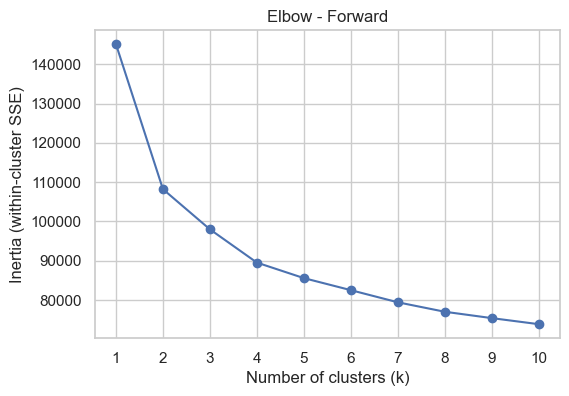


 Elbow plot for Goalkeeper


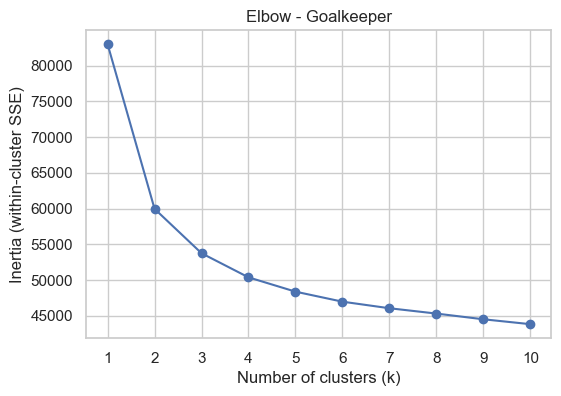


 Elbow plot for Midfielder


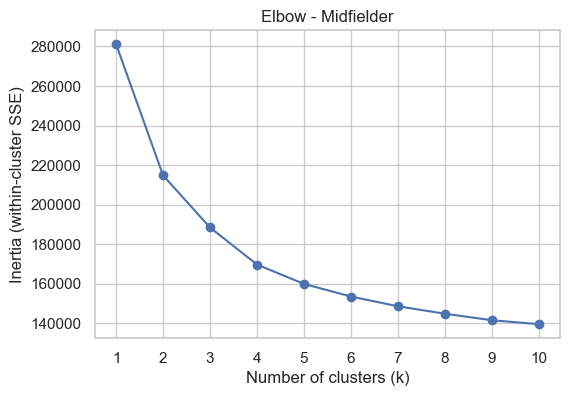


 Elbow plot for Defender


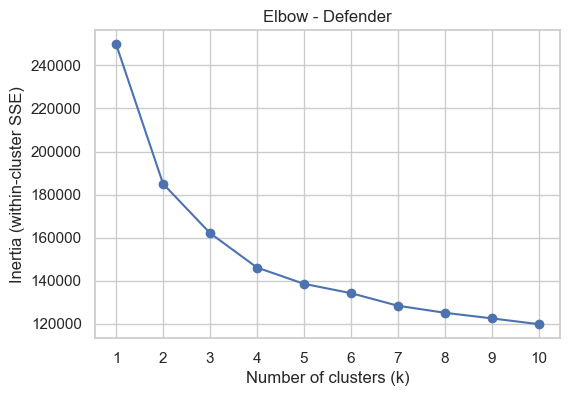

In [98]:


def elbow_method(X, max_k=10, title="Elbow Plot"):
    """Plots inertia vs. k for 1..max_k."""
    inertias = []
    for k in range(1, max_k + 1):
        km = KMeans(n_clusters=k, n_init='auto', random_state=42)
        km.fit(X)
        inertias.append(km.inertia_)
    
    plt.figure(figsize=(6, 4))
    plt.plot(range(1, max_k + 1), inertias, marker='o')
    plt.xticks(range(1, max_k + 1))
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Inertia (within-cluster SSE)')
    plt.title(title)
    plt.grid(True)
    plt.show()

# Loop through the groups you stored earlier
for group_name, (gdf, X_scaled) in group_dfs.items():
    print(f"\n Elbow plot for {group_name}")
    elbow_method(X_scaled, max_k=10, title=f"Elbow - {group_name}")

Based on the grapgh we opted to use these k values

In [99]:
chosen_k = {
    'Forward':    4,  
    'Midfielder': 4,
    'Defender':   3,
    'Goalkeeper': 3
}

applies KMeans clustering using optimal k for each position group
labels each player with their cluster ID
stores the updated data for future analysis(ANOVA)

In [100]:
for group, (gdf, X_scaled) in group_dfs.items():
    k = chosen_k[group]
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    gdf['cluster'] = kmeans.fit_predict(X_scaled)
    group_dfs[group] = gdf

2d plot of the cluster distribution

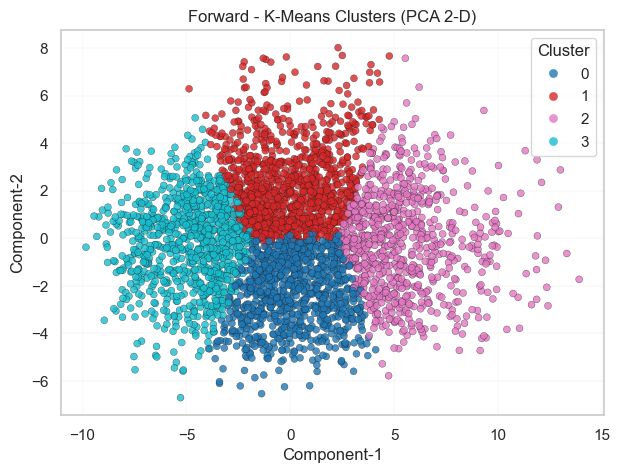

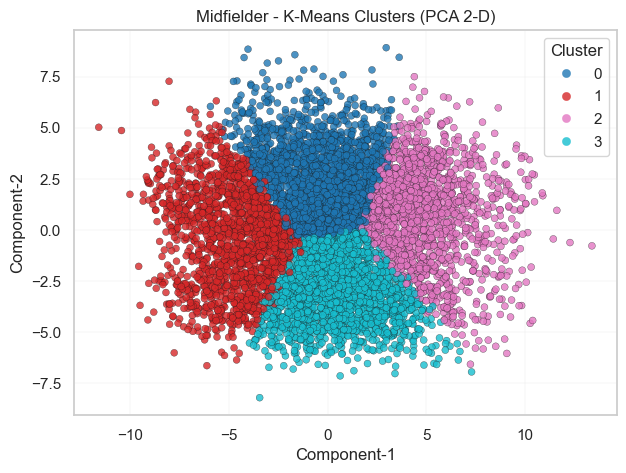

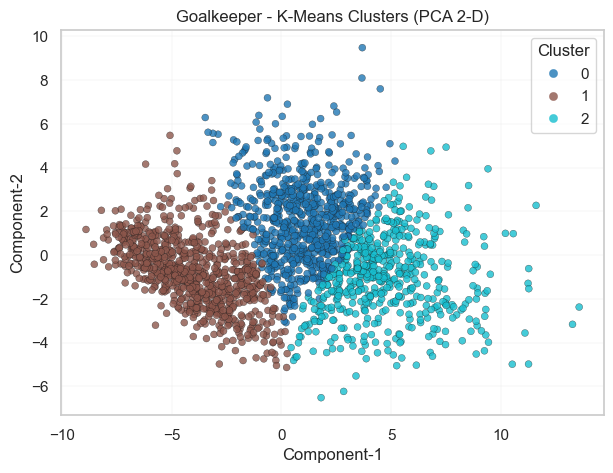

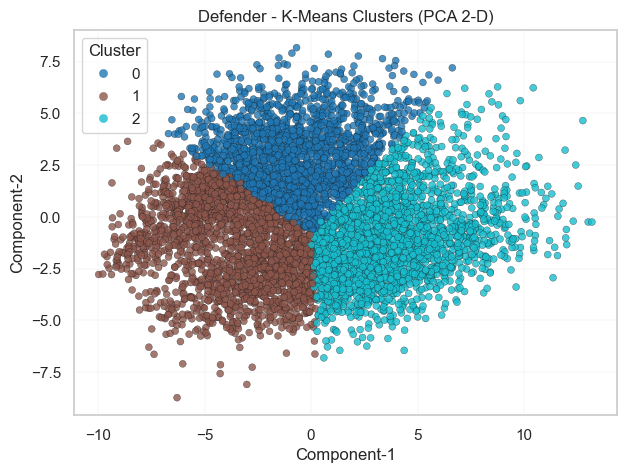

In [101]:



def plot_clusters(group_name, use_tsne=False):
 
    gdf = group_dfs[group_name]                    
    X_scaled = scalers[group_name].transform(gdf[attributes])  

    if use_tsne:
        from sklearn.manifold import TSNE
        X_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X_scaled)
        title_suffix = "t-SNE"
    else:
        X_2d = PCA(n_components=2, random_state=42).fit_transform(X_scaled)
        title_suffix = "PCA"


    plt.figure(figsize=(7, 5))
    scatter = plt.scatter(
        X_2d[:, 0], X_2d[:, 1],
        c=gdf['cluster'], cmap='tab10',
        s=25, alpha=0.8, edgecolor='k', linewidth=0.25
    )

    plt.title(f"{group_name} - K-Means Clusters ({title_suffix} 2-D)")
    plt.xlabel('Component-1')
    plt.ylabel('Component-2')
    plt.grid(True, alpha=0.4, linewidth=0.3)

    # version‑safe legend with a title
    handles, labels = scatter.legend_elements()
    legend = plt.legend(handles, labels, title="Cluster", loc='best')

    plt.show()


plot_clusters('Forward')              
plot_clusters('Midfielder')
plot_clusters('Goalkeeper')
plot_clusters('Defender')


Show the mean for all the clusters in each player group

In [102]:
profile = (
    group_dfs['Forward']
    .groupby('cluster')[attributes + ['Log_Value']]
    .mean()
    .round(1)
)
display(profile)

,Crossing,Finishing,Heading Accuracy,Short Passing,Volleys,Dribbling,Curve,FK Accuracy,Long Passing,Ball Control,Acceleration,Sprint Speed,Agility,Reactions,Balance,Shot Power,Jumping,Stamina,Strength,Long Shots,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Marking,Standing Tackle,Sliding Tackle,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,PAC,SHO,PAS,DRI,DEF,PHY,Log_Value
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,57.7,62.3,50.6,61.1,54.7,67.5,55.9,48.1,51.9,66.1,78.4,77.7,75.9,60.3,73.3,63.8,61.7,63.0,58.2,57.8,47.7,30.0,62.6,58.8,56.9,59.5,33.1,31.9,29.9,10.4,10.3,10.5,10.4,10.3,78.0,61.1,57.7,67.9,33.6,57.5,13.9
1,45.3,68.9,68.2,59.6,61.6,63.2,51.0,43.4,44.7,65.5,63.9,66.1,62.2,64.0,58.6,69.7,69.2,64.4,76.3,61.3,57.8,25.5,68.2,55.1,64.6,62.8,28.1,25.2,22.2,10.4,10.6,10.7,10.6,10.7,65.1,66.9,52.4,63.6,30.2,69.3,13.9
2,65.0,74.4,66.1,71.0,69.5,75.2,68.0,60.3,61.0,75.3,76.2,75.9,75.8,73.5,71.5,75.9,71.2,71.8,69.9,70.5,62.8,37.1,75.6,69.4,69.6,73.0,38.6,36.1,31.7,10.5,10.8,10.7,10.6,10.5,76.0,73.5,67.3,75.1,39.7,69.0,15.4
3,39.3,59.1,53.6,50.0,47.8,56.4,42.8,35.0,37.3,56.4,67.2,67.4,63.0,52.4,65.2,57.0,61.3,56.0,59.2,51.3,39.9,19.2,55.5,48.5,56.7,49.6,21.1,20.3,19.5,10.2,10.1,10.2,10.1,10.1,67.3,56.2,44.6,57.3,23.6,54.7,12.8


In [103]:
profile = (
    group_dfs['Midfielder']
    .groupby('cluster')[attributes + ['Log_Value']]
    .mean()
    .round(1)
)
display(profile)

,Crossing,Finishing,Heading Accuracy,Short Passing,Volleys,Dribbling,Curve,FK Accuracy,Long Passing,Ball Control,Acceleration,Sprint Speed,Agility,Reactions,Balance,Shot Power,Jumping,Stamina,Strength,Long Shots,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Marking,Standing Tackle,Sliding Tackle,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,PAC,SHO,PAS,DRI,DEF,PHY,Log_Value
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,53.8,49.0,55.7,67.4,44.7,61.8,51.5,48.4,64.3,65.4,63.5,62.7,65.5,63.1,66.9,61.5,65.2,72.0,67.6,54.9,66.5,62.1,55.7,61.7,50.0,61.7,60.6,63.2,60.0,10.4,10.6,10.5,10.5,10.6,63.0,52.9,61.4,63.6,61.2,68.4,13.8
1,47.8,45.2,43.8,58.7,40.5,56.6,45.3,41.5,54.0,58.0,66.5,66.1,65.0,52.6,69.1,52.0,56.8,57.0,52.4,44.0,48.1,39.9,49.9,53.4,46.1,50.2,40.7,43.7,42.8,10.1,10.1,10.1,10.0,10.1,66.3,46.4,53.2,58.3,42.0,52.9,12.7
2,69.0,64.5,58.3,75.7,62.3,73.8,70.1,65.5,72.4,75.6,69.3,68.0,73.1,72.3,72.4,73.9,65.4,75.5,67.2,70.3,68.3,62.9,69.2,73.3,63.3,72.9,61.0,62.9,58.5,10.4,10.6,10.6,10.7,10.6,68.6,67.6,72.6,74.1,61.5,69.5,15.3
3,62.6,61.7,47.8,65.6,55.6,69.8,61.5,55.7,59.4,68.6,77.1,75.6,77.2,62.2,75.3,65.1,60.9,65.7,56.4,60.7,49.1,35.2,63.5,63.8,58.0,62.2,37.1,36.6,34.2,10.6,10.6,10.6,10.5,10.5,76.3,61.8,63.1,70.1,37.4,57.5,14.1


In [104]:
profile = (
    group_dfs['Goalkeeper']
    .groupby('cluster')[attributes + ['Log_Value']]
    .mean()
    .round(1)
)
display(profile)

,Crossing,Finishing,Heading Accuracy,Short Passing,Volleys,Dribbling,Curve,FK Accuracy,Long Passing,Ball Control,Acceleration,Sprint Speed,Agility,Reactions,Balance,Shot Power,Jumping,Stamina,Strength,Long Shots,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Marking,Standing Tackle,Sliding Tackle,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,PAC,SHO,PAS,DRI,DEF,PHY,Log_Value
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,15.2,13.8,15.4,27.9,14.3,15.3,15.8,15.3,26.4,21.2,41.6,41.9,41.8,59.6,45.8,45.9,58.2,32.5,61.4,14.5,26.6,18.8,13.1,36.9,21.4,42.5,16.1,15.2,15.1,64.6,62.0,61.0,62.8,65.4,64.6,62.0,61.0,65.4,41.8,62.8,12.9
1,12.2,7.7,12.3,23.2,7.8,10.3,12.3,12.1,22.8,15.5,28.2,28.6,32.8,50.4,37.3,42.9,51.4,24.8,55.1,7.8,22.8,11.0,6.8,34.9,14.7,33.8,10.7,12.1,12.0,59.9,58.2,57.0,57.2,60.6,59.9,58.2,57.0,60.6,28.4,57.2,12.8
2,14.9,13.2,14.9,31.4,13.6,15.6,15.9,15.3,30.5,23.2,44.8,44.8,46.5,70.0,45.2,52.9,64.8,34.2,65.9,14.1,29.2,19.7,12.9,47.3,22.3,53.4,17.0,14.6,14.3,74.5,71.7,70.3,73.4,76.0,74.5,71.7,70.3,76.0,44.8,73.4,14.6


In [105]:
profile = (
    group_dfs['Defender']
    .groupby('cluster')[attributes + ['Log_Value']]
    .mean()
    .round(1)
)
display(profile)

,Crossing,Finishing,Heading Accuracy,Short Passing,Volleys,Dribbling,Curve,FK Accuracy,Long Passing,Ball Control,Acceleration,Sprint Speed,Agility,Reactions,Balance,Shot Power,Jumping,Stamina,Strength,Long Shots,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Marking,Standing Tackle,Sliding Tackle,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,PAC,SHO,PAS,DRI,DEF,PHY,Log_Value
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,41.3,30.9,68.8,61.0,31.7,46.3,36.0,33.6,55.5,56.9,54.1,56.4,51.8,64.1,52.6,50.6,71.0,65.0,78.8,34.1,70.5,67.5,35.4,42.6,41.2,61.6,68.0,69.7,67.3,10.7,10.7,10.5,10.6,10.6,55.4,36.3,50.0,51.3,68.5,73.3,14.0
1,44.4,28.3,53.5,50.8,28.9,46.0,34.9,31.3,42.6,50.1,64.3,64.4,57.9,53.9,61.7,39.4,66.0,61.9,63.9,28.9,56.4,56.3,38.5,38.5,37.8,48.0,56.0,60.3,58.5,10.1,10.1,10.1,10.1,10.2,64.3,31.7,44.1,49.6,57.4,62.0,12.9
2,65.7,45.6,60.0,66.5,44.1,64.9,57.6,48.5,61.4,66.6,72.5,73.2,70.1,66.0,69.2,61.1,70.1,74.3,67.5,52.0,67.9,66.4,57.6,57.3,48.8,63.7,66.1,68.4,67.3,10.7,10.7,10.6,10.6,10.6,72.9,50.7,62.4,66.2,66.4,69.5,14.4


Show top 10 highest OVAs in each cluster with their Log_Value for each of the position groups

In [106]:
for c in sorted(group_dfs['Forward']['cluster'].unique()):
    print(f"\nCluster {c} - 10 highest-rated players (by OVA):")
    
    (group_dfs['Forward']
       .loc[group_dfs['Forward']['cluster'] == c,
            ['Name', 'OVA', 'Log_Value']]      
       .sort_values('OVA', ascending=False)      # highest OVA at the top
       .head(10)                                  # take the top 10
       .pipe(display))


Cluster 0 - 10 highest-rated players (by OVA):


,Name,OVA,Log_Value
1555,Muo Cadete,75,15.687313
1862,A. Mitriță,75,15.830414
1983,C. Ejuke,75,16.257858
2044,T. Bongonda,74,15.607270
2204,G. Caprari,74,15.424949
2220,C. Hudson-Odoi,74,16.118096
2279,M. van Bergen,74,15.955577
2491,Brahim,74,16.118096
2537,P. Roberts,73,15.761421
2576,A. Ba Loua,73,15.341567



Cluster 1 - 10 highest-rated players (by OVA):


,Name,OVA,Log_Value
848,B. Dost,78,16.066802
1107,A. Mitrović,77,16.454568
1240,H. Diallo,76,16.166886
1259,L. Ajorque,76,16.118096
1351,J. Mateta,76,16.523561
1352,F. Klos,76,15.607270
1383,A. Budimir,76,15.830414
1404,D. Ginczek,76,15.830414
1408,S. Andersson,76,15.830414
1432,V. Muriqi,76,16.118096



Cluster 2 - 10 highest-rated players (by OVA):


,Name,OVA,Log_Value
0,L. Messi,93,18.455082
1,Cristiano Ronaldo,92,17.958645
4,Neymar Jr,91,18.698312
5,R. Lewandowski,91,18.525041
6,M. Salah,90,18.607160
8,K. Mbappé,90,19.038565
11,S. Mané,90,18.607160
15,K. Benzema,89,18.240357
17,S. Agüero,89,18.240357
18,R. Sterling,88,18.556085



Cluster 3 - 10 highest-rated players (by OVA):


,Name,OVA,Log_Value
10127,H. Al Hazaa,65,13.493928
10841,A. Sobczyk,64,14.077876
10846,S. Moghanlou,64,13.681980
10901,Pablo Moreno,64,14.220976
10906,M. Prieto,64,12.524530
10960,A. Jackson-Hamel,64,13.458837
10997,R. Hardie,64,14.077876
11103,Thuram,64,13.262127
11184,A. Díaz,64,14.151984
11219,G. Raspadori,64,14.151984


In [107]:
for c in sorted(group_dfs['Defender']['cluster'].unique()):
    print(f"\nCluster {c} – 5 highest‑rated players (by OVA):")
    
    (group_dfs['Defender']
       .loc[group_dfs['Defender']['cluster'] == c,
            ['Name', 'OVA', 'Log_Value']]        # keep only the columns you want
       .sort_values('OVA', ascending=False)      # highest OVA at the top
       .head(10)                                  # take the top 5
       .pipe(display))


Cluster 0 – 5 highest‑rated players (by OVA):


,Name,OVA,Log_Value
25,K. Koulibaly,88,18.152801
39,G. Chiellini,87,16.860033
67,M. Škriniar,85,18.020203
95,D. Godín,85,16.677711
100,J. Giménez,84,17.776324
110,N. Süle,84,17.867296
113,Felipe,84,17.182806
132,S. de Vrij,84,17.504390
168,A. Romagnoli,83,17.633223
189,K. Manolas,83,17.327056



Cluster 1 – 5 highest‑rated players (by OVA):


,Name,OVA,Log_Value
4784,B. Castillo,70,14.690980
4850,L. Venuti,70,14.603968
5012,M. Pineida,70,14.220976
5607,O. Ribera,69,14.077876
5838,Andoni López,69,14.557448
6462,B. Carabalí,68,14.346139
6540,A. Sissoko,68,14.771022
6805,I. Kabore,68,14.808763
6843,Z. Sanusi,68,14.771022
7177,Diogo Mateus,68,14.077876



Cluster 2 – 5 highest‑rated players (by OVA):


,Name,OVA,Log_Value
10,V. van Dijk,90,18.542898
16,Sergio Ramos,89,17.327056
30,T. Alexander-Arnold,87,18.551709
32,A. Robertson,87,18.320860
33,A. Laporte,87,18.342719
50,Carvajal,86,17.934548
51,R. Varane,86,18.099097
55,Piqué,86,17.296751
56,M. Hummels,86,17.654963
60,Jordi Alba,86,17.717483


In [108]:
for c in sorted(group_dfs['Goalkeeper']['cluster'].unique()):
    print(f"\nCluster {c} – 5 highest‑rated players (by OVA):")
    
    (group_dfs['Goalkeeper']
       .loc[group_dfs['Goalkeeper']['cluster'] == c,
            ['Name', 'OVA', 'Log_Value']]        # keep only the columns you want
       .sort_values('OVA', ascending=False)      # highest OVA at the top
       .head(10)                                  # take the top 5
       .pipe(display))


Cluster 0 – 5 highest‑rated players (by OVA):


,Name,OVA,Log_Value
1532,L. Kalinić,75,15.123844
2355,A. Hruška,74,13.493928
2828,A. Gabbarini,73,13.171155
4062,B. Medina,71,13.737550
4071,T. Cardozo,71,15.096445
4073,E. Horvath,71,14.508658
4149,Daniel Guimarães,71,13.304687
4194,S. Marinović,71,14.285515
4219,Charles,71,14.457365
4252,D. Phillips,71,14.603968



Cluster 1 – 5 highest‑rated players (by OVA):


,Name,OVA,Log_Value
2721,D. Akpeyi,73,13.171155
2804,J. Pinos,73,14.508658
3230,A. Cordaz,72,12.429220
3543,G. Bushchan,72,14.808763
3715,A. Bodart,72,15.226498
4008,C. Cáceda,71,14.077876
4105,Mateus Pasinato,71,14.077876
4501,Eduardo Fonseira,71,14.285515
4566,N. Baumann,70,14.946913
4567,D. Schmidt,70,14.151984



Cluster 2 – 5 highest‑rated players (by OVA):


,Name,OVA,Log_Value
2,J. Oblak,91,18.603002
7,Alisson,90,18.440483
9,M. ter Stegen,90,18.515991
13,T. Courtois,89,18.222230
14,M. Neuer,89,16.677711
22,Ederson,88,18.337299
24,S. Handanovič,88,16.118096
38,K. Navas,87,17.073607
42,W. Szczęsny,87,17.785802
46,H. Lloris,87,17.073607


In [109]:
for c in sorted(group_dfs['Midfielder']['cluster'].unique()):
    print(f"\nCluster {c} – 5 highest‑rated players (by OVA):")
    
    (group_dfs['Midfielder']
       .loc[group_dfs['Midfielder']['cluster'] == c,
            ['Name', 'OVA', 'Log_Value']]        # keep only the columns you want
       .sort_values('OVA', ascending=False)      # highest OVA at the top
       .head(10)                                  # take the top 5
       .pipe(display))


Cluster 0 – 5 highest‑rated players (by OVA):


,Name,OVA,Log_Value
357,Javi Martínez,81,16.705882
530,B. Kamara,79,16.993564
531,D. Rice,79,17.327056
563,T. Bakayoko,79,16.811243
581,W. Barrios,79,9.105091
651,S. Nzonzi,79,16.341239
739,Palhinha,78,16.835935
795,C. Kramer,78,16.300417
832,D. Demme,78,16.418200
882,J. Guilavogui,78,16.300417



Cluster 1 – 5 highest‑rated players (by OVA):


,Name,OVA,Log_Value
6361,Avilés,68,14.808763
8500,Gaspar,66,14.457365
8511,B. Çamoğlu,66,14.077876
9209,L. Flores,66,13.997833
9779,C. Rivas,65,13.815512
9798,Conrado,65,14.285515
10089,L. Pavia,65,13.815512
10176,J. Arrascaita,65,13.560620
10379,A. Rojas,65,13.304687
10474,Joni Montiel,65,14.285515



Cluster 2 – 5 highest‑rated players (by OVA):


,Name,OVA,Log_Value
3,K. De Bruyne,91,18.675323
12,Casemiro,89,18.320860
19,N. Kanté,88,18.172219
20,J. Kimmich,88,18.450240
27,T. Kroos,88,18.287149
29,J. Sancho,87,18.635792
34,Bruno Fernandes,87,18.474222
35,Fabinho,87,18.298513
36,H. Son,87,18.258162
40,Sergio Busquets,87,17.840862



Cluster 3 – 5 highest‑rated players (by OVA):


,Name,OVA,Log_Value
107,K. Coman,84,17.918154
278,M. Diaby,81,17.747336
305,Everton,81,17.479072
377,S. Ardero,80,9.105091
396,Laure Santeiro,80,16.993564
399,L. Bailey,80,17.296751
407,A. Saint-Maximin,80,17.327056
446,Deulofeu,80,17.034386
529,J. Ikoné,79,17.385043
703,L. Díaz,78,17.249498


Show the top contriubuters to PC1(component 1 or x axis) and PC2(component 2 or y axis) for each of the position groups, gives a rough idea why a player is clutered in this group

In [110]:
X_scaled = scalers['Forward'].transform(group_dfs['Forward'][attributes])
pca = PCA(n_components=2).fit(X_scaled)

loadings_df = pd.DataFrame(pca.components_.T, index=attributes, columns=['PC1', 'PC2'])
print("Top contributors to PC1:")
print(loadings_df['PC1'].sort_values(key=abs, ascending=False).head(10))
print("Top contributors to PC2:")
print(loadings_df['PC2'].sort_values(key=abs, ascending=False).head(10))

Top contributors to PC1:
PAS              0.228995
Ball Control     0.226232
Short Passing    0.224256
DRI              0.221810
Composure        0.216674
SHO              0.215441
Reactions        0.213963
Positioning      0.213672
Dribbling        0.212607
Vision           0.207017
Name: PC1, dtype: float64
Top contributors to PC2:
Heading Accuracy    0.316860
Acceleration       -0.308133
Strength            0.300936
PAC                -0.293600
Balance            -0.285060
Agility            -0.284872
Sprint Speed       -0.265975
PHY                 0.246214
Penalties           0.178958
Finishing           0.177714
Name: PC2, dtype: float64


In [111]:
X_scaled = scalers['Defender'].transform(group_dfs['Defender'][attributes])
pca = PCA(n_components=2).fit(X_scaled)

loadings_df = pd.DataFrame(pca.components_.T, index=attributes, columns=['PC1', 'PC2'])
print("Top contributors to PC1:")
print(loadings_df['PC1'].sort_values(key=abs, ascending=False).head(10))
print("Top contributors to PC2:")
print(loadings_df['PC2'].sort_values(key=abs, ascending=False).head(10))

Top contributors to PC1:
PAS              0.238359
DRI              0.219815
Ball Control     0.219554
SHO              0.215370
Short Passing    0.209434
Vision           0.205282
Dribbling        0.203323
Long Passing     0.200213
Long Shots       0.200158
Curve            0.197443
Name: PC1, dtype: float64
Top contributors to PC2:
Heading Accuracy    0.300578
Strength            0.285100
DEF                 0.254413
Acceleration       -0.253303
PHY                 0.247560
PAC                -0.241881
Balance            -0.235636
Marking             0.231929
Standing Tackle     0.230644
Agility            -0.220395
Name: PC2, dtype: float64


In [112]:
X_scaled = scalers['Midfielder'].transform(group_dfs['Midfielder'][attributes])
pca = PCA(n_components=2).fit(X_scaled)

loadings_df = pd.DataFrame(pca.components_.T, index=attributes, columns=['PC1', 'PC2'])
print("Top contributors to PC1:")
print(loadings_df['PC1'].sort_values(key=abs, ascending=False).head(10))
print("Top contributors to PC2:")
print(loadings_df['PC2'].sort_values(key=abs, ascending=False).head(10))

Top contributors to PC1:
PAS              0.248433
Ball Control     0.234673
Vision           0.227822
SHO              0.226663
DRI              0.226110
Composure        0.223014
Short Passing    0.222209
Long Shots       0.220698
Reactions        0.220246
Dribbling        0.213973
Name: PC1, dtype: float64
Top contributors to PC2:
DEF                0.297672
Standing Tackle    0.290983
Sliding Tackle     0.290609
Interceptions      0.281884
Marking            0.270403
Acceleration      -0.238614
PAC               -0.238070
Aggression         0.232032
PHY                0.222683
Sprint Speed      -0.222509
Name: PC2, dtype: float64


In [113]:
X_scaled = scalers['Goalkeeper'].transform(group_dfs['Goalkeeper'][attributes])
pca = PCA(n_components=2).fit(X_scaled)

loadings_df = pd.DataFrame(pca.components_.T, index=attributes, columns=['PC1', 'PC2'])
print("Top contributors to PC1:")
print(loadings_df['PC1'].sort_values(key=abs, ascending=False).head(10))
print("Top contributors to PC2:")
print(loadings_df['PC2'].sort_values(key=abs, ascending=False).head(10))

Top contributors to PC1:
GK Positioning    0.211224
PHY               0.211224
GK Diving         0.210823
PAC               0.210823
GK Reflexes       0.209857
DRI               0.209857
GK Handling       0.204511
SHO               0.204511
Reactions         0.202606
PAS               0.199839
Name: PC1, dtype: float64
Top contributors to PC2:
Finishing          0.213356
Volleys            0.209052
Long Shots         0.207217
Sliding Tackle     0.205819
SHO               -0.203778
GK Handling       -0.203778
Crossing           0.203053
Standing Tackle    0.198963
Balance            0.190147
Curve              0.190018
Name: PC2, dtype: float64


We will now perform ANOVA testing to determine whether there is a difference in Log_value among the clusters of each position group

### H0: the mean Log_value is the same on all position groups
### H1: at least one cluster has a different mean Log_value compared to the others

code below iterates through all the position groups and performs one way ANOVA testing to test whether the mean Log_value differes significantly accross the clusters 

In [115]:
from scipy.stats import f_oneway

VALUE_COL = 'Log_Value'  # or 'value_eur'

for group_name, df in group_dfs.items():
    print(f"\n=== {group_name} ===")
    
    # Central Limit Theorem (CLT) assumption for normality
    for c in sorted(df['cluster'].unique()):
        n = len(df[df['cluster'] == c])
        print(f"  Cluster {c}: n={n} ≥ 500 → CLT applies, normality assumed.")

    # Prepare samples per cluster
    samples = [df[df['cluster'] == c][VALUE_COL].values for c in sorted(df['cluster'].unique())]

    # One-way ANOVA
    F_stat, p_anova = f_oneway(*samples)
    print(f"  ANOVA: F = {F_stat:.3f}, p = {p_anova:.4f}")

    # Hypothesis test interpretation
    if p_anova < 0.05:
        print("  → Reject H₀: At least one cluster mean is significantly different.")
    else:
        print("  → Fail to reject H₀: No significant difference between cluster means.")



=== Forward ===
  Cluster 0: n=878 ≥ 500 → CLT applies, normality assumed.
  Cluster 1: n=1048 ≥ 500 → CLT applies, normality assumed.
  Cluster 2: n=785 ≥ 500 → CLT applies, normality assumed.
  Cluster 3: n=917 ≥ 500 → CLT applies, normality assumed.
  ANOVA: F = 1002.081, p = 0.0000
  → Reject H₀: At least one cluster mean is significantly different.

=== Goalkeeper ===
  Cluster 0: n=738 ≥ 500 → CLT applies, normality assumed.
  Cluster 1: n=814 ≥ 500 → CLT applies, normality assumed.
  Cluster 2: n=523 ≥ 500 → CLT applies, normality assumed.
  ANOVA: F = 384.132, p = 0.0000
  → Reject H₀: At least one cluster mean is significantly different.

=== Midfielder ===
  Cluster 0: n=2050 ≥ 500 → CLT applies, normality assumed.
  Cluster 1: n=1595 ≥ 500 → CLT applies, normality assumed.
  Cluster 2: n=1503 ≥ 500 → CLT applies, normality assumed.
  Cluster 3: n=1881 ≥ 500 → CLT applies, normality assumed.
  ANOVA: F = 1641.166, p = 0.0000
  → Reject H₀: At least one cluster mean is signif

in conclusion since the p-value from the ANOVA test is less than 0.05, we reject the null hypothesis. This provides statistical evidence to support the alternative hypothesis — that at least one of the cluster means differs significantly from the others

use ANNOVA to further understand EDA#2, which we test whether there is a significant effect of age on the player's OVA and market value

### H0: All group means are equal
### H1: At least noe group mean is significantly different

In [117]:
# Step 1: Group Age into Categories
bins = [15, 20, 25, 30, 35, 50]
labels = ['16-20', '21-25', '26-30', '31-35', '36+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

# Optional: Drop rows with missing values in relevant columns
df_anova = df.dropna(subset=['Age_Group', 'OVA', 'Log_Value'])

# Step 2: ANOVA for OVA across Age Groups
print("=== ANOVA: OVA by Age Group ===")
groups_ova = [group['OVA'].values for _, group in df_anova.groupby('Age_Group')]
F_ova, p_ova = f_oneway(*groups_ova)

# Hypothesis for OVA
print("H₀: The mean OVA is equal across all age groups.")
print("H₁: At least one age group has a different mean OVA.")
print(f"F-statistic: {F_ova:.2f}")
print(f"P-value: {p_ova:.4f}")
if p_ova < 0.05:
    print("→ Reject H₀: Age has a significant effect on OVA.")
else:
    print("→ Fail to reject H₀: No significant difference in OVA across age groups.")

# Step 3: ANOVA for Market Value (Log_Value) across Age Groups
print("\n=== ANOVA: Market Value by Age Group ===")
groups_val = [group['Log_Value'].values for _, group in df_anova.groupby('Age_Group')]
F_val, p_val = f_oneway(*groups_val)

# Hypothesis for Market Value
print("H₀: The mean market value is equal across all age groups.")
print("H₁: At least one age group has a different mean market value.")
print(f"F-statistic: {F_val:.2f}")
print(f"P-value: {p_val:.4f}")
if p_val < 0.05:
    print("→ Reject H₀: Age has a significant effect on market value.")
else:
    print("→ Fail to reject H₀: No significant difference in market value across age groups.")


=== ANOVA: OVA by Age Group ===
H₀: The mean OVA is equal across all age groups.
H₁: At least one age group has a different mean OVA.
F-statistic: 462.94
P-value: 0.0000
→ Reject H₀: Age has a significant effect on OVA.

=== ANOVA: Market Value by Age Group ===
H₀: The mean market value is equal across all age groups.
H₁: At least one age group has a different mean market value.
F-statistic: 146.46
P-value: 0.0000
→ Reject H₀: Age has a significant effect on market value.


C:\Users\Simon\AppData\Local\Temp\ipykernel_2692\3249602210.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups_ova = [group['OVA'].values for _, group in df_anova.groupby('Age_Group')]
C:\Users\Simon\AppData\Local\Temp\ipykernel_2692\3249602210.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups_val = [group['Log_Value'].values for _, group in df_anova.groupby('Age_Group')]


# Insights and Conclusion

In this dataset here are insights about how the players corolate with their OVA and Log values with respect to their attributes:
* 